In [1]:
import numpy as np
import pandas as pd 
import scipy as sp
import scipy.signal as spg
import cmath
import scipy.constants as const
import matplotlib.pyplot as plt
import sys
sys.path.append('/Users/leayamashiro/whispering_gallery_MAIN/calibrated/analysis')
import useful_functions as uf
import seaborn as sns 
sns.set_theme()


## Load in COMSOL results

In [ ]:
double_zotefoam = uf.fix_csv('EigenRadiusSweep_Al&_DoubleZotefoamContactModel_2.5to5.5GHz.csv', '/Users/leayamashiro/whispering_gallery_MAIN/calibrated/new_Q/Q_data/')
just_alumina = uf.fix_csv('EigenRadiusSweep_Al&NO_Zotefoam_2.5to5.5GHz.csv', '/Users/leayamashiro/whispering_gallery_MAIN/calibrated/new_Q/Q_data/')


,% r_zotefoam (m),search_freq (Hz),Eigenfrequency (GHz),Frequency (GHz),Quality factor (1)
0,0.019056,2.500000e+09,2.300291+0.117896j,2.300291,9.755613
1,0.019056,2.500000e+09,2.300411+0.000436j,2.300411,2637.063354
2,0.019056,2.500000e+09,2.300565+0.117133j,2.300565,9.820323
3,0.019056,2.500000e+09,2.300917+0.000439j,2.300917,2622.483514
4,0.019056,2.500000e+09,2.313770+0.089817j,2.313770,12.880450
...,...,...,...,...,...
8395,0.076225,5.500000e+09,5.611835+0.018993j,5.611835,147.735701
8396,0.076225,5.500000e+09,5.612646+0.031202j,5.612646,89.940104
8397,0.076225,5.500000e+09,5.613588+0.008750j,5.613588,320.792391
8398,0.076225,5.500000e+09,5.616529+0.036203j,5.616529,77.568935


In [3]:
just_alumina = uf.fix_csv('EigenRadiusSweep_Al&NO_Zotefoam_2.5to5.5GHz.csv', '/Users/leayamashiro/whispering_gallery_MAIN/calibrated/new_Q/Q_data/')


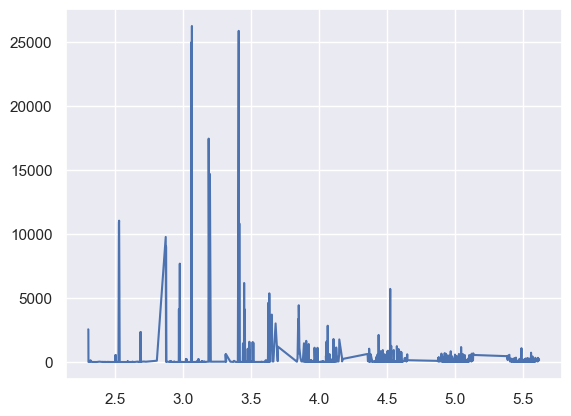

In [5]:
plt.plot(just_alumina['Frequency (GHz)'], just_alumina['Quality factor (1)'])

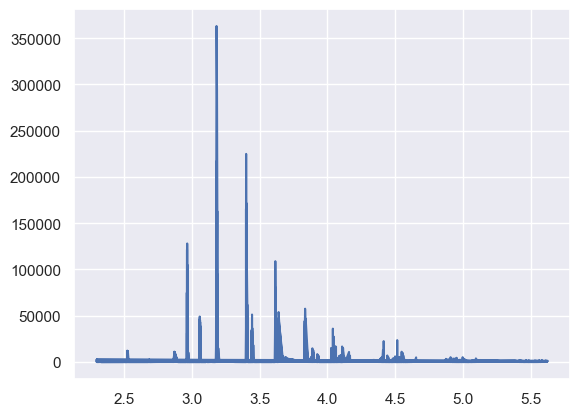

In [6]:
plt.plot(double_zotefoam['Frequency (GHz)'], double_zotefoam['Quality factor (1)'])

## Separate by Radius

In [7]:
quarter_R = double_zotefoam[double_zotefoam['% r_zotefoam (m)'].round(6)==0.019056]
third_R = double_zotefoam[double_zotefoam['% r_zotefoam (m)'].round(6)==0.025408]
half_R = double_zotefoam[double_zotefoam['% r_zotefoam (m)'].round(7)==0.0381125]
twothirds_R = double_zotefoam[double_zotefoam['% r_zotefoam (m)'].round(6)==0.050817]
full_R = double_zotefoam[double_zotefoam['% r_zotefoam (m)'].round(6)==0.076225]

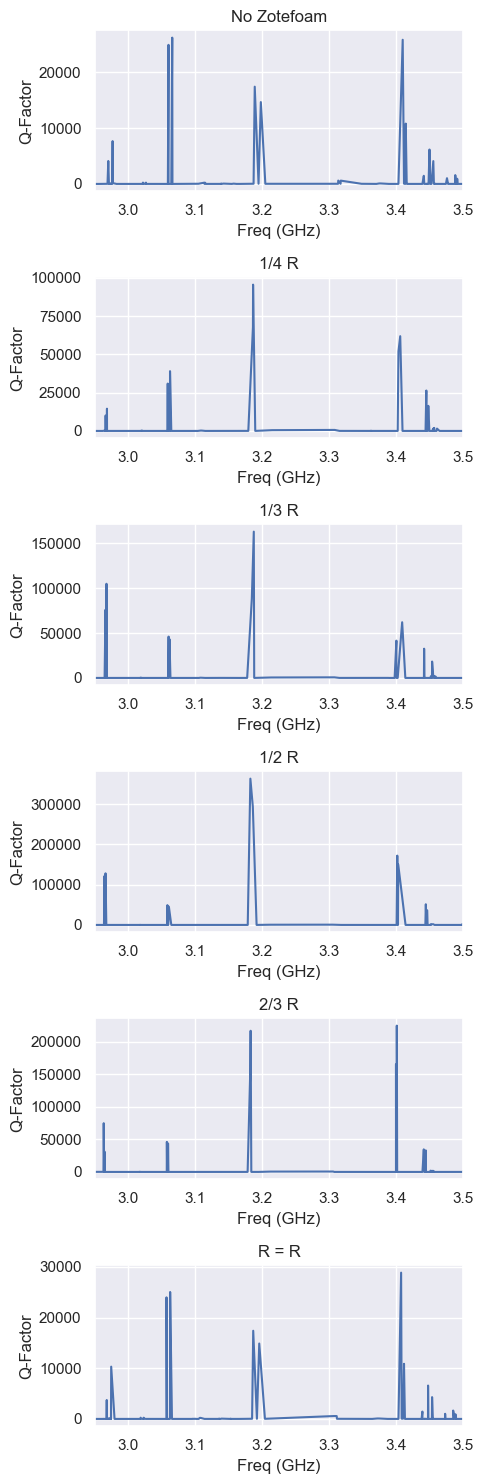

In [8]:
fig, ax = plt.subplots(6, 1, figsize = (5, 15))

ax[0].plot(just_alumina['Frequency (GHz)'], just_alumina['Quality factor (1)'])
ax[0].set_title('No Zotefoam')
ax[0].set_xlabel('Freq (GHz)')
ax[0].set_ylabel('Q-Factor')

ax[1].plot(quarter_R['Frequency (GHz)'], quarter_R['Quality factor (1)'])
ax[1].set_title('1/4 R')
ax[1].set_xlabel('Freq (GHz)')
ax[1].set_ylabel('Q-Factor')

ax[2].plot(third_R['Frequency (GHz)'], third_R['Quality factor (1)'])
ax[2].set_title('1/3 R')
ax[2].set_xlabel('Freq (GHz)')
ax[2].set_ylabel('Q-Factor')

ax[3].plot(half_R['Frequency (GHz)'], half_R['Quality factor (1)'])
ax[3].set_title('1/2 R')
ax[3].set_xlabel('Freq (GHz)')
ax[3].set_ylabel('Q-Factor')

ax[4].plot(twothirds_R['Frequency (GHz)'], twothirds_R['Quality factor (1)'])
ax[4].set_title('2/3 R')
ax[4].set_xlabel('Freq (GHz)')
ax[4].set_ylabel('Q-Factor')

ax[5].plot(full_R['Frequency (GHz)'], full_R['Quality factor (1)'])
ax[5].set_title('R = R')
ax[5].set_xlabel('Freq (GHz)')
ax[5].set_ylabel('Q-Factor')

plt.setp(ax, xlim=(2.95, 3.5))
plt.tight_layout()

In [9]:
twothirds_R

,% r_zotefoam (m),search_freq (Hz),Eigenfrequency (GHz),Frequency (GHz),Quality factor (1)
5040,0.050817,2.500000e+09,2.299252+0.000432j,2.299252,2664.126575
5041,0.050817,2.500000e+09,2.299396+0.000431j,2.299396,2665.862074
5042,0.050817,2.500000e+09,2.300377+0.117745j,2.300377,9.768434
5043,0.050817,2.500000e+09,2.300733+0.117212j,2.300733,9.814423
5044,0.050817,2.500000e+09,2.311231+0.090098j,2.311231,12.826167
...,...,...,...,...,...
6715,0.050817,5.500000e+09,5.601990+0.050281j,5.601990,55.707115
6716,0.050817,5.500000e+09,5.609208+0.004551j,5.609208,616.293449
6717,0.050817,5.500000e+09,5.609895+0.025923j,5.609895,108.203210
6718,0.050817,5.500000e+09,5.611894+0.041350j,5.611894,67.859248


yeah really just need to do a threshold thing rather than the find peaks because it is missing some peaks due to the way that the function works (distance from point next to it) -- it's missing some where there are two eigenvalues that are conjugates

## Get Q-factor Peaks

In [10]:
alumina_peaks = just_alumina[just_alumina['Quality factor (1)']>=3000].reset_index(drop=True)
quarter_R_Qpeaks = quarter_R[quarter_R['Quality factor (1)']>=10000].reset_index(drop=True)
third_R_Qpeaks = third_R[third_R['Quality factor (1)']>=7000].reset_index(drop=True)
half_R_Qpeaks = half_R[half_R['Quality factor (1)']>=10000].reset_index(drop=True)
twothirds_R_Qpeaks = twothirds_R[twothirds_R['Quality factor (1)']>=10000].reset_index(drop=True)
full_R_Qpeaks = full_R[full_R['Quality factor (1)']>=3000].reset_index(drop=True)

In [ ]:
# indices to drop: 12, 18
full_R_Qpeaks
full_R_peakfreqs = full_R['Frequency (GHz)'].iloc[0:18].drop(12)

## Extract frequencies from the Q-peaks

In [141]:
alumina_peakfreqs = alumina_peaks['Frequency (GHz)'].iloc[0:18].drop(12)
quarter_R_peakfreqs = quarter_R_Qpeaks['Frequency (GHz)'].iloc[0:18].drop(12)
third_R_peakfreqs = third_R_Qpeaks['Frequency (GHz)']
half_R_peakfreqs = half_R_Qpeaks['Frequency (GHz)']
twothirds_R_peakfreqs = twothirds_R_Qpeaks['Frequency (GHz)'].iloc[0:17]
full_R_peakfreqs = full_R_Qpeaks['Frequency (GHz)'].iloc[0:18].drop(12)

In [142]:
full_R_peakfreqs

0     2.528290
1     2.529899
2     2.871407
3     2.873661
4     2.969044
5     2.975817
6     3.058627
7     3.064110
8     3.187654
9     3.196782
10    3.408404
11    3.412799
13    3.454396
14    3.626200
15    3.633106
16    3.648331
17    3.652200
Name: Frequency (GHz), dtype: float64

In [54]:
len(quarter_R_peakfreqs)

16

In [70]:
quarter_R_peakfreqs.values

array([2.52726952, 2.52820941, 2.87234164, 2.87359847, 2.97054038,
       2.97198004, 3.06048365, 3.06150155, 3.18880012, 3.19325069,
       3.40692049, 3.41325879, 3.45094514, 3.62547338, 3.63204478,
       3.64273771, 3.64880508])

In [143]:
print(len(alumina_peakfreqs))
print(len(quarter_R_peakfreqs))
print(len(third_R_peakfreqs))
print(len(half_R_peakfreqs))
print(len(twothirds_R_peakfreqs))
print(len(full_R_peakfreqs))

17
17
17
17
17
17


In [483]:
radius_column = [0, 1/4, 1/3, 1/2, 2/3]
radius_column_full = [0, 0.25, 0.3333333333333333, 0.5, 0.6666666666666666, 1]

In [484]:
resonances_df_full = pd.DataFrame([alumina_peakfreqs.values, 
                              quarter_R_peakfreqs.values, 
                              third_R_peakfreqs.values, 
                              half_R_peakfreqs.values, 
                              twothirds_R_peakfreqs.values, 
                              full_R_peakfreqs.values])

resonances_df_full.insert(0, 'Radius', radius_column_full)

In [485]:
resonances_df_full

,Radius,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,0.000000,2.529201,2.530838,2.873249,2.875583,2.970204,2.976651,3.060040,3.065609,3.188710,3.197803,3.409475,3.414007,3.455147,3.627450,3.634368,3.648997,3.652435
1,0.250000,2.527270,2.528209,2.872342,2.873598,2.970540,2.971980,3.060484,3.061502,3.188800,3.193251,3.406920,3.413259,3.450945,3.625473,3.632045,3.642738,3.648805
2,0.333333,2.527084,2.527941,2.873036,2.873241,2.969833,2.971673,3.059710,3.062964,3.187907,3.192902,3.407525,3.411023,3.452663,3.624767,3.630728,3.645074,3.647750
3,0.500000,2.526884,2.527239,2.870592,2.873036,2.968589,2.970445,3.058250,3.060525,3.186949,3.189982,3.404671,3.408845,3.442302,3.619576,3.628911,3.635994,3.647687
4,0.666667,2.526875,2.527013,2.870120,2.872852,2.968526,2.969769,3.057661,3.060248,3.187040,3.189045,3.404922,3.407486,3.446101,3.620756,3.625981,3.638705,3.643501
5,1.000000,2.528290,2.529899,2.871407,2.873661,2.969044,2.975817,3.058627,3.064110,3.187654,3.196782,3.408404,3.412799,3.454396,3.626200,3.633106,3.648331,3.652200


In [281]:

resonances_df = pd.DataFrame([alumina_peakfreqs.values, 
                              quarter_R_peakfreqs.values, 
                              third_R_peakfreqs.values, 
                              half_R_peakfreqs.values, 
                              twothirds_R_peakfreqs.values, 
                              ])

# resonances_df = pd.DataFrame([alumina_peakfreqs.values, 
#                               quarter_R_peakfreqs.values, 
#                               third_R_peakfreqs.values, 
#                               half_R_peakfreqs.values, 
#                               twothirds_R_peakfreqs.values, 
#                               full_R_peakfreqs.values])


resonances_df.insert(0, 'Radius', radius_column)

In [282]:
resonances_df

,Radius,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,0.000000,2.529201,2.530838,2.873249,2.875583,2.970204,2.976651,3.060040,3.065609,3.188710,3.197803,3.409475,3.414007,3.455147,3.627450,3.634368,3.648997,3.652435
1,0.250000,2.527270,2.528209,2.872342,2.873598,2.970540,2.971980,3.060484,3.061502,3.188800,3.193251,3.406920,3.413259,3.450945,3.625473,3.632045,3.642738,3.648805
2,0.333333,2.527084,2.527941,2.873036,2.873241,2.969833,2.971673,3.059710,3.062964,3.187907,3.192902,3.407525,3.411023,3.452663,3.624767,3.630728,3.645074,3.647750
3,0.500000,2.526884,2.527239,2.870592,2.873036,2.968589,2.970445,3.058250,3.060525,3.186949,3.189982,3.404671,3.408845,3.442302,3.619576,3.628911,3.635994,3.647687
4,0.666667,2.526875,2.527013,2.870120,2.872852,2.968526,2.969769,3.057661,3.060248,3.187040,3.189045,3.404922,3.407486,3.446101,3.620756,3.625981,3.638705,3.643501


In [283]:
resonances_df.columns

Index(['Radius', 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16], dtype='object')

In [284]:
column_names = ['Radius', 
                'TE 2.5 I', 'TE 2.5 II', 
                'TM 2.87 I', 'TM 2.87 II', 
                'TE 2.97 I', 'TE 2.97 II', 
                'TM 3.05 I', 'TM 3.05 II', 
                'TE 3.19 I', 'TE 3.19 II', 
                'TE 3.41 I', 'TE 3.41 II', 
                'TM 3.45', 
                'TE 3.62 I', 'TE 3.62 II', 
                'TM 3.64 I', 'TM 3.64 II']

In [486]:
resonances_df.columns = column_names
resonances_df_full.columns = column_names

In [286]:
resonances_df

,Radius,TE 2.5 I,TE 2.5 II,TM 2.87 I,TM 2.87 II,TE 2.97 I,TE 2.97 II,TM 3.05 I,TM 3.05 II,TE 3.19 I,TE 3.19 II,TE 3.41 I,TE 3.41 II,TM 3.45,TE 3.62 I,TE 3.62 II,TM 3.64 I,TM 3.64 II
0,0.000000,2.529201,2.530838,2.873249,2.875583,2.970204,2.976651,3.060040,3.065609,3.188710,3.197803,3.409475,3.414007,3.455147,3.627450,3.634368,3.648997,3.652435
1,0.250000,2.527270,2.528209,2.872342,2.873598,2.970540,2.971980,3.060484,3.061502,3.188800,3.193251,3.406920,3.413259,3.450945,3.625473,3.632045,3.642738,3.648805
2,0.333333,2.527084,2.527941,2.873036,2.873241,2.969833,2.971673,3.059710,3.062964,3.187907,3.192902,3.407525,3.411023,3.452663,3.624767,3.630728,3.645074,3.647750
3,0.500000,2.526884,2.527239,2.870592,2.873036,2.968589,2.970445,3.058250,3.060525,3.186949,3.189982,3.404671,3.408845,3.442302,3.619576,3.628911,3.635994,3.647687
4,0.666667,2.526875,2.527013,2.870120,2.872852,2.968526,2.969769,3.057661,3.060248,3.187040,3.189045,3.404922,3.407486,3.446101,3.620756,3.625981,3.638705,3.643501


In [487]:
resonances_df_full

,Radius,TE 2.5 I,TE 2.5 II,TM 2.87 I,TM 2.87 II,TE 2.97 I,TE 2.97 II,TM 3.05 I,TM 3.05 II,TE 3.19 I,TE 3.19 II,TE 3.41 I,TE 3.41 II,TM 3.45,TE 3.62 I,TE 3.62 II,TM 3.64 I,TM 3.64 II
0,0.000000,2.529201,2.530838,2.873249,2.875583,2.970204,2.976651,3.060040,3.065609,3.188710,3.197803,3.409475,3.414007,3.455147,3.627450,3.634368,3.648997,3.652435
1,0.250000,2.527270,2.528209,2.872342,2.873598,2.970540,2.971980,3.060484,3.061502,3.188800,3.193251,3.406920,3.413259,3.450945,3.625473,3.632045,3.642738,3.648805
2,0.333333,2.527084,2.527941,2.873036,2.873241,2.969833,2.971673,3.059710,3.062964,3.187907,3.192902,3.407525,3.411023,3.452663,3.624767,3.630728,3.645074,3.647750
3,0.500000,2.526884,2.527239,2.870592,2.873036,2.968589,2.970445,3.058250,3.060525,3.186949,3.189982,3.404671,3.408845,3.442302,3.619576,3.628911,3.635994,3.647687
4,0.666667,2.526875,2.527013,2.870120,2.872852,2.968526,2.969769,3.057661,3.060248,3.187040,3.189045,3.404922,3.407486,3.446101,3.620756,3.625981,3.638705,3.643501
5,1.000000,2.528290,2.529899,2.871407,2.873661,2.969044,2.975817,3.058627,3.064110,3.187654,3.196782,3.408404,3.412799,3.454396,3.626200,3.633106,3.648331,3.652200


In [287]:
# getting delta f vs. radius
RTwoThirds_deltas = resonances_df.iloc[-1, 1:] - resonances_df.iloc[0, 1:]
Rhalf_deltas = resonances_df.iloc[-2, 1:] - resonances_df.iloc[0, 1:]
Rthird_deltas = resonances_df.iloc[2, 1:] - resonances_df.iloc[0, 1:]
Rquarter_deltas = resonances_df.iloc[1, 1:] - resonances_df.iloc[0, 1:]

In [ ]:
# relative_deltas = 

In [288]:
resonances_df['TE 2.5 I'].iloc[3] - resonances_df['TE 2.5 I'].iloc[0] == Rhalf_deltas[0]

True

In [289]:
radius_deltas = pd.DataFrame([resonances_df.iloc[0], 
                              Rquarter_deltas, 
                              Rthird_deltas, 
                              Rhalf_deltas, 
                              RTwoThirds_deltas], index=None)

radius_deltas['Radius'] = radius_column

# radius_deltas.columns = column_names


In [290]:
radius_deltas

,Radius,TE 2.5 I,TE 2.5 II,TM 2.87 I,TM 2.87 II,TE 2.97 I,TE 2.97 II,TM 3.05 I,TM 3.05 II,TE 3.19 I,TE 3.19 II,TE 3.41 I,TE 3.41 II,TM 3.45,TE 3.62 I,TE 3.62 II,TM 3.64 I,TM 3.64 II
0,0.000000,2.529201,2.530838,2.873249,2.875583,2.970204,2.976651,3.060040,3.065609,3.188710,3.197803,3.409475,3.414007,3.455147,3.627450,3.634368,3.648997,3.652435
Unnamed 0,0.250000,-0.001932,-0.002628,-0.000907,-0.001984,0.000337,-0.004671,0.000444,-0.004107,0.000090,-0.004552,-0.002554,-0.000749,-0.004202,-0.001976,-0.002323,-0.006259,-0.003630
Unnamed 1,0.333333,-0.002117,-0.002897,-0.000213,-0.002342,-0.000371,-0.004978,-0.000330,-0.002644,-0.000803,-0.004901,-0.001949,-0.002984,-0.002484,-0.002683,-0.003640,-0.003924,-0.004685
Unnamed 2,0.500000,-0.002317,-0.003598,-0.002657,-0.002547,-0.001615,-0.006206,-0.001790,-0.005084,-0.001761,-0.007821,-0.004804,-0.005163,-0.012845,-0.007874,-0.005458,-0.013003,-0.004748
Unnamed 3,0.666667,-0.002327,-0.003825,-0.003129,-0.002731,-0.001678,-0.006882,-0.002379,-0.005360,-0.001670,-0.008759,-0.004552,-0.006522,-0.009046,-0.006693,-0.008387,-0.010293,-0.008934


In [291]:
# Rename specific index labels
radius_deltas.rename(index={
    0: 'Baseline Freqs',
    'Unnamed 0': 1,
    'Unnamed 1': 2,
    'Unnamed 2': 3,
    'Unnamed 3': 4,
}, inplace=True)

In [292]:
radius_deltas

,Radius,TE 2.5 I,TE 2.5 II,TM 2.87 I,TM 2.87 II,TE 2.97 I,TE 2.97 II,TM 3.05 I,TM 3.05 II,TE 3.19 I,TE 3.19 II,TE 3.41 I,TE 3.41 II,TM 3.45,TE 3.62 I,TE 3.62 II,TM 3.64 I,TM 3.64 II
Baseline Freqs,0.000000,2.529201,2.530838,2.873249,2.875583,2.970204,2.976651,3.060040,3.065609,3.188710,3.197803,3.409475,3.414007,3.455147,3.627450,3.634368,3.648997,3.652435
1,0.250000,-0.001932,-0.002628,-0.000907,-0.001984,0.000337,-0.004671,0.000444,-0.004107,0.000090,-0.004552,-0.002554,-0.000749,-0.004202,-0.001976,-0.002323,-0.006259,-0.003630
2,0.333333,-0.002117,-0.002897,-0.000213,-0.002342,-0.000371,-0.004978,-0.000330,-0.002644,-0.000803,-0.004901,-0.001949,-0.002984,-0.002484,-0.002683,-0.003640,-0.003924,-0.004685
3,0.500000,-0.002317,-0.003598,-0.002657,-0.002547,-0.001615,-0.006206,-0.001790,-0.005084,-0.001761,-0.007821,-0.004804,-0.005163,-0.012845,-0.007874,-0.005458,-0.013003,-0.004748
4,0.666667,-0.002327,-0.003825,-0.003129,-0.002731,-0.001678,-0.006882,-0.002379,-0.005360,-0.001670,-0.008759,-0.004552,-0.006522,-0.009046,-0.006693,-0.008387,-0.010293,-0.008934


In [293]:
radius_deltas.index

Index(['Baseline Freqs', 1, 2, 3, 4], dtype='object')

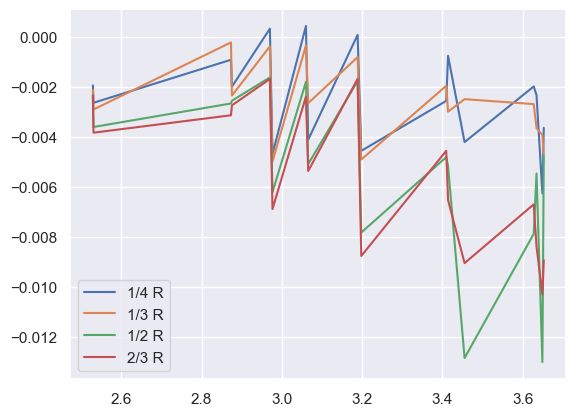

In [294]:
plt.plot(radius_deltas.iloc[0, 1:], radius_deltas.iloc[1, 1:], label = '1/4 R')
plt.plot(radius_deltas.iloc[0, 1:], radius_deltas.iloc[2, 1:], label = '1/3 R')
plt.plot(radius_deltas.iloc[0, 1:], radius_deltas.iloc[3, 1:], label = '1/2 R')
plt.plot(radius_deltas.iloc[0, 1:], radius_deltas.iloc[4, 1:], label = '2/3 R')
plt.legend()

In [295]:
radius_deltas

,Radius,TE 2.5 I,TE 2.5 II,TM 2.87 I,TM 2.87 II,TE 2.97 I,TE 2.97 II,TM 3.05 I,TM 3.05 II,TE 3.19 I,TE 3.19 II,TE 3.41 I,TE 3.41 II,TM 3.45,TE 3.62 I,TE 3.62 II,TM 3.64 I,TM 3.64 II
Baseline Freqs,0.000000,2.529201,2.530838,2.873249,2.875583,2.970204,2.976651,3.060040,3.065609,3.188710,3.197803,3.409475,3.414007,3.455147,3.627450,3.634368,3.648997,3.652435
1,0.250000,-0.001932,-0.002628,-0.000907,-0.001984,0.000337,-0.004671,0.000444,-0.004107,0.000090,-0.004552,-0.002554,-0.000749,-0.004202,-0.001976,-0.002323,-0.006259,-0.003630
2,0.333333,-0.002117,-0.002897,-0.000213,-0.002342,-0.000371,-0.004978,-0.000330,-0.002644,-0.000803,-0.004901,-0.001949,-0.002984,-0.002484,-0.002683,-0.003640,-0.003924,-0.004685
3,0.500000,-0.002317,-0.003598,-0.002657,-0.002547,-0.001615,-0.006206,-0.001790,-0.005084,-0.001761,-0.007821,-0.004804,-0.005163,-0.012845,-0.007874,-0.005458,-0.013003,-0.004748
4,0.666667,-0.002327,-0.003825,-0.003129,-0.002731,-0.001678,-0.006882,-0.002379,-0.005360,-0.001670,-0.008759,-0.004552,-0.006522,-0.009046,-0.006693,-0.008387,-0.010293,-0.008934


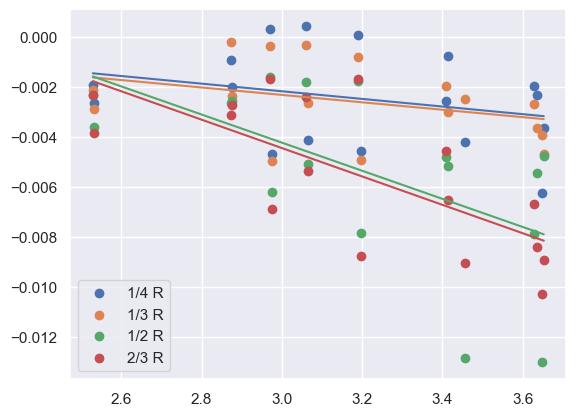

In [296]:
# quarter R deltas
quarter_R_delta_slope, quarter_R_deltas_int = np.polyfit(radius_deltas.iloc[0, 1:], 
                                                         radius_deltas.iloc[1, 1:], 1)
quarter_R_y_fit = quarter_R_delta_slope * radius_deltas.iloc[0, 1:] + quarter_R_deltas_int
plt.scatter(radius_deltas.iloc[0, 1:], radius_deltas.iloc[1, 1:], label = '1/4 R')
plt.plot(radius_deltas.iloc[0, 1:], quarter_R_y_fit)

# third R deltas 
third_R_delta_slope, third_R_deltas_int = np.polyfit(radius_deltas.iloc[0, 1:], 
                                                     radius_deltas.iloc[2, 1:], 1)
third_R_y_fit = third_R_delta_slope * radius_deltas.iloc[0, 1:] + third_R_deltas_int
plt.scatter(radius_deltas.iloc[0, 1:], radius_deltas.iloc[2, 1:], label = '1/3 R')
plt.plot(radius_deltas.iloc[0, 1:], third_R_y_fit)

# half R deltas 
half_R_delta_slope, half_R_deltas_int = np.polyfit(radius_deltas.iloc[0, 1:], 
                                                   radius_deltas.iloc[3, 1:], 1)
half_R_y_fit = half_R_delta_slope * radius_deltas.iloc[0, 1:] + half_R_deltas_int
plt.scatter(radius_deltas.iloc[0, 1:], radius_deltas.iloc[3, 1:], label = '1/2 R')
plt.plot(radius_deltas.iloc[0, 1:], half_R_y_fit)

# two thirds R deltas 
twothirds_R_delta_slope, twothirds_R_deltas_int = np.polyfit(radius_deltas.iloc[0, 1:], 
                                                             radius_deltas.iloc[4, 1:], 1)
twothirds_R_y_fit = twothirds_R_delta_slope * radius_deltas.iloc[0, 1:] + twothirds_R_deltas_int
plt.scatter(radius_deltas.iloc[0, 1:], radius_deltas.iloc[4, 1:], label = '2/3 R')
plt.plot(radius_deltas.iloc[0, 1:], twothirds_R_y_fit)

plt.legend()

Text(0.5, 1.0, 'Frequency Shift Magnitude, $\\Delta f$  vs. TE/TM Location')

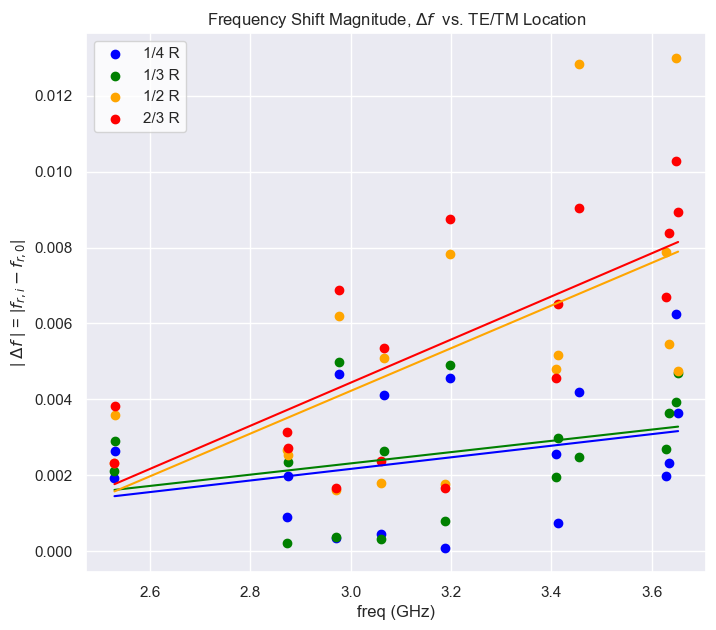

In [514]:
# MAG VERSION
plt.figure(figsize = (8, 7))
# quarter R deltas
quarter_R_delta_slope, quarter_R_deltas_int = np.polyfit(radius_deltas.iloc[0, 1:], 
                                                         radius_deltas.iloc[1, 1:], 1)
quarter_R_y_fit = quarter_R_delta_slope * radius_deltas.iloc[0, 1:] + quarter_R_deltas_int
plt.scatter(radius_deltas.iloc[0, 1:], np.abs(radius_deltas.iloc[1, 1:]), label = '1/4 R', color = 'blue')
plt.plot(radius_deltas.iloc[0, 1:], np.abs(quarter_R_y_fit), color = 'blue')

# third R deltas 
third_R_delta_slope, third_R_deltas_int = np.polyfit(radius_deltas.iloc[0, 1:], 
                                                     radius_deltas.iloc[2, 1:], 1)
third_R_y_fit = third_R_delta_slope * radius_deltas.iloc[0, 1:] + third_R_deltas_int
plt.scatter(radius_deltas.iloc[0, 1:], np.abs(radius_deltas.iloc[2, 1:]), label = '1/3 R', color = 'green')
plt.plot(radius_deltas.iloc[0, 1:], np.abs(third_R_y_fit), color = 'green')

# half R deltas 
half_R_delta_slope, half_R_deltas_int = np.polyfit(radius_deltas.iloc[0, 1:], 
                                                   radius_deltas.iloc[3, 1:], 1)
half_R_y_fit = half_R_delta_slope * radius_deltas.iloc[0, 1:] + half_R_deltas_int
plt.scatter(radius_deltas.iloc[0, 1:], np.abs(radius_deltas.iloc[3, 1:]), label = '1/2 R', color = 'orange')
plt.plot(radius_deltas.iloc[0, 1:], np.abs(half_R_y_fit), color = 'orange')

# two thirds R deltas 
twothirds_R_delta_slope, twothirds_R_deltas_int = np.polyfit(radius_deltas.iloc[0, 1:], 
                                                             radius_deltas.iloc[4, 1:], 1)
twothirds_R_y_fit = twothirds_R_delta_slope * radius_deltas.iloc[0, 1:] + twothirds_R_deltas_int
plt.scatter(radius_deltas.iloc[0, 1:], np.abs(radius_deltas.iloc[4, 1:]), label = '2/3 R', color = 'red')
plt.plot(radius_deltas.iloc[0, 1:], np.abs(twothirds_R_y_fit), color = 'red')

plt.legend(facecolor='white')
plt.xlabel('freq (GHz)')
plt.ylabel(r'| $\Delta f$ | = |$f_{r,i} - f_{r,0}$|')
plt.title(f'Frequency Shift Magnitude, $\Delta f$  vs. TE/TM Location')


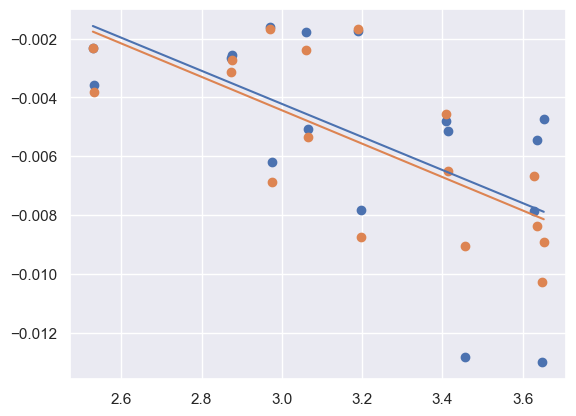

In [298]:

# half R deltas 
half_R_delta_slope, half_R_deltas_int = np.polyfit(radius_deltas.iloc[0, 1:], 
                                                         radius_deltas.iloc[3, 1:], 1)
half_R_y_fit = half_R_delta_slope * radius_deltas.iloc[0, 1:] + half_R_deltas_int
plt.scatter(radius_deltas.iloc[0, 1:], radius_deltas.iloc[3, 1:], label = '1/3 R')
plt.plot(radius_deltas.iloc[0, 1:], half_R_y_fit)

# two thirds R deltas 
twothirds_R_delta_slope, twothirds_R_deltas_int = np.polyfit(radius_deltas.iloc[0, 1:], 
                                                         radius_deltas.iloc[4, 1:], 1)
twothirds_R_y_fit = twothirds_R_delta_slope * radius_deltas.iloc[0, 1:] + twothirds_R_deltas_int
plt.scatter(radius_deltas.iloc[0, 1:], radius_deltas.iloc[4, 1:], label = '1/3 R')
plt.plot(radius_deltas.iloc[0, 1:], twothirds_R_y_fit)

In [299]:
twothirds_R_y_fit[0] - half_R_y_fit[0]

-0.00019138366719190225

In [300]:
half_R_y_fit[0]

-0.0015748606592134867

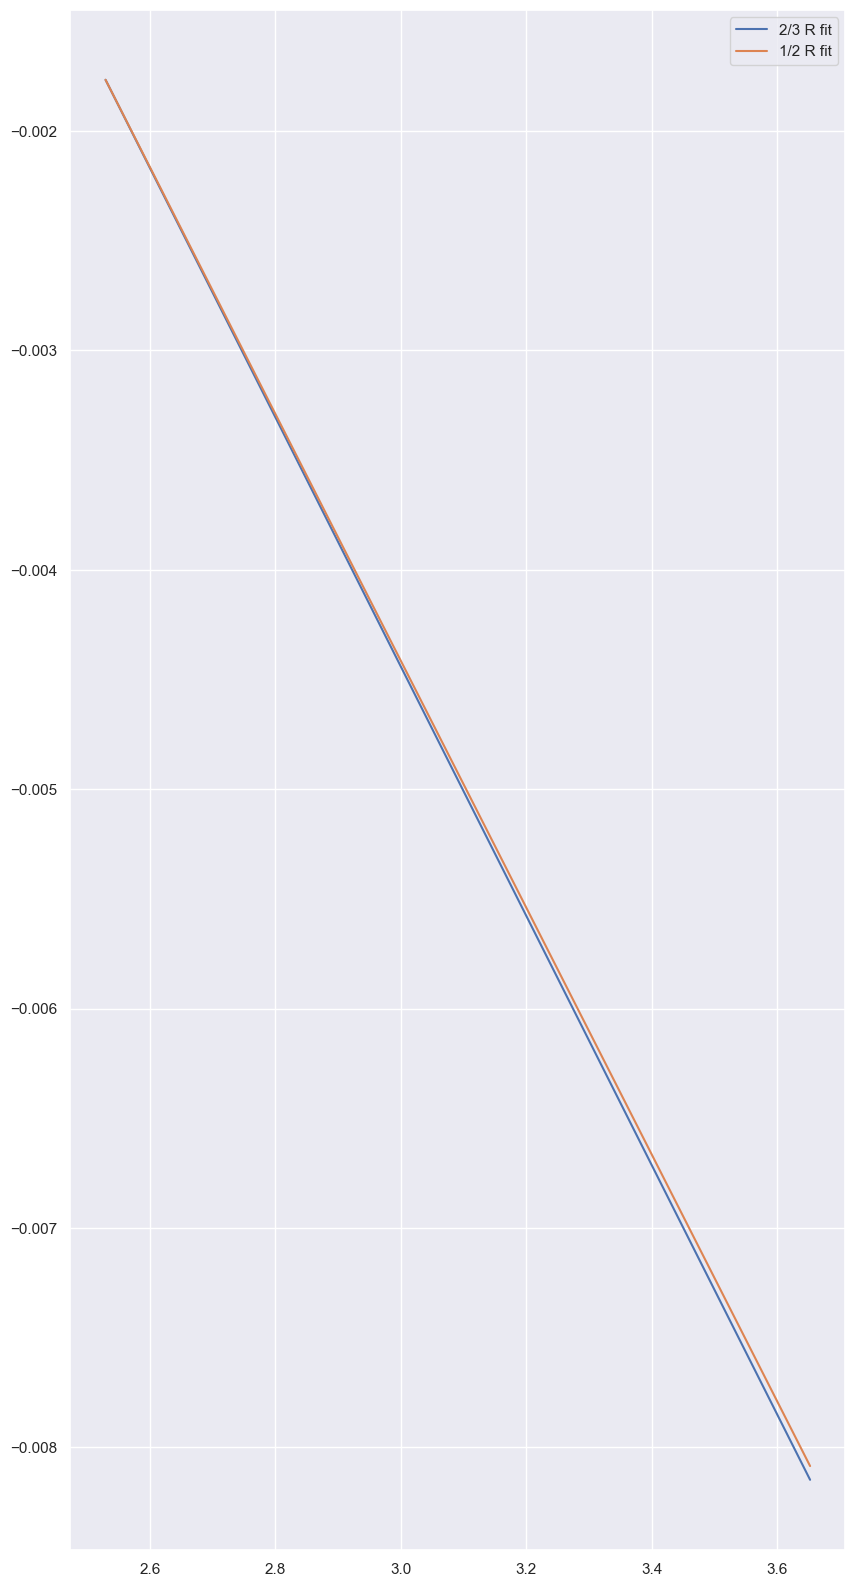

In [301]:
plt.figure(figsize = (10, 20))
plt.plot(radius_deltas.iloc[0, 1:], twothirds_R_y_fit, label = '2/3 R fit')
plt.plot(radius_deltas.iloc[0, 1:], half_R_y_fit + (twothirds_R_y_fit[0] - half_R_y_fit[0]), label = '1/2 R fit')
#plt.plot(radius_deltas.iloc[0, 1:], half_R_y_fit - twothirds_R_y_fit, label = '1/2 fit - 1/3 fit')
plt.legend()

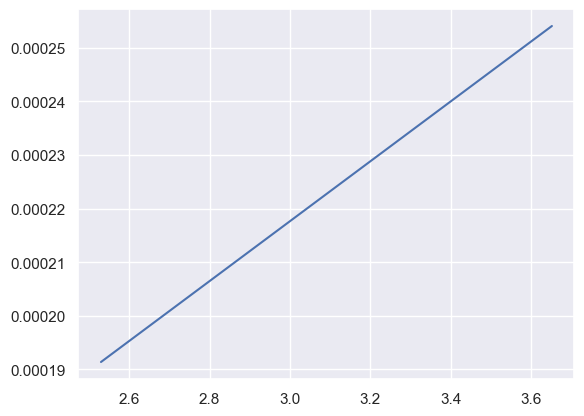

In [302]:
plt.plot(radius_deltas.iloc[0, 1:], half_R_y_fit - twothirds_R_y_fit, label = '1/2 fit - 1/3 fit')

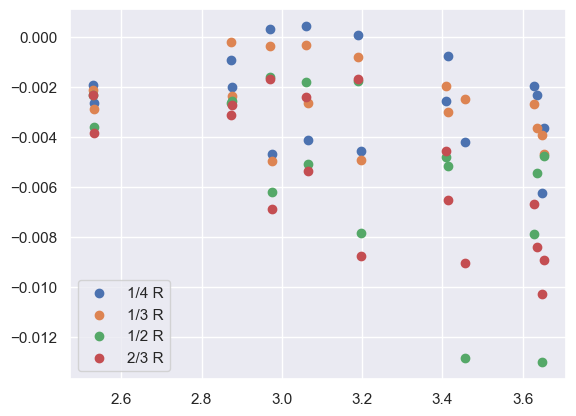

In [303]:
plt.scatter(radius_deltas.iloc[0, 1:], radius_deltas.iloc[1, 1:], label = '1/4 R')
plt.scatter(radius_deltas.iloc[0, 1:], radius_deltas.iloc[2, 1:], label = '1/3 R')
plt.scatter(radius_deltas.iloc[0, 1:], radius_deltas.iloc[3, 1:], label = '1/2 R')
plt.scatter(radius_deltas.iloc[0, 1:], radius_deltas.iloc[4, 1:], label = '2/3 R')
plt.legend()

In [307]:
res_deltas = resonances_df.iloc[-1, 1:] - resonances_df.iloc[0, 1:]
res_deltas

TE 2.5 I     -0.002327
TE 2.5 II    -0.003825
TM 2.87 I    -0.003129
TM 2.87 II   -0.002731
TE 2.97 I    -0.001678
TE 2.97 II   -0.006882
TM 3.05 I    -0.002379
TM 3.05 II   -0.005360
TE 3.19 I    -0.001670
TE 3.19 II   -0.008759
TE 3.41 I    -0.004552
TE 3.41 II   -0.006522
TM 3.45      -0.009046
TE 3.62 I    -0.006693
TE 3.62 II   -0.008387
TM 3.64 I    -0.010293
TM 3.64 II   -0.008934
dtype: float64

In [308]:
deltas = pd.DataFrame([resonances_df.iloc[0, 1:].values, res_deltas])
deltas

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,2.529201,2.530838,2.873249,2.875583,2.970204,2.976651,3.060040,3.065609,3.18871,3.197803,3.409475,3.414007,3.455147,3.627450,3.634368,3.648997,3.652435
1,-0.002327,-0.003825,-0.003129,-0.002731,-0.001678,-0.006882,-0.002379,-0.005360,-0.00167,-0.008759,-0.004552,-0.006522,-0.009046,-0.006693,-0.008387,-0.010293,-0.008934


Text(0, 0.5, '$\\Delta f$')

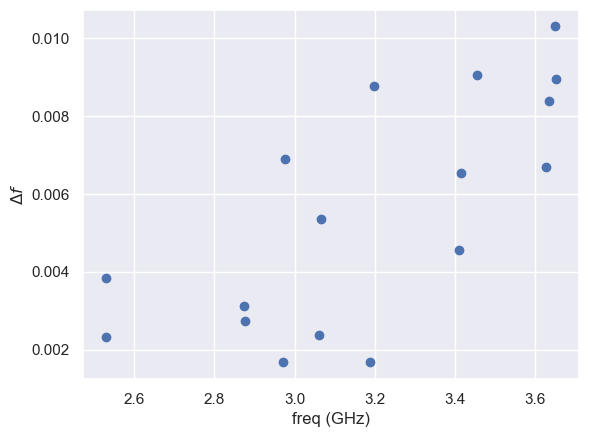

In [309]:
plt.scatter(deltas.iloc[0], np.abs(deltas.iloc[1]))
plt.xlabel('freq (GHz)')
plt.ylabel(f'$\Delta f$')

Text(0.5, 1.0, 'Total Frequency Shift, $\\Delta f$  vs. TE/TM Location')

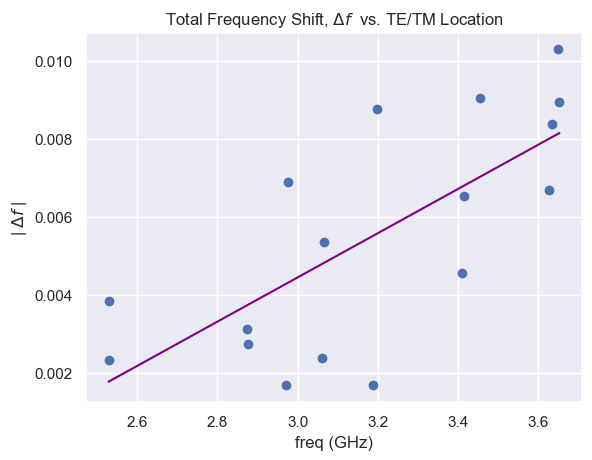

In [310]:
slope, int = np.polyfit(deltas.iloc[0], np.abs(deltas.iloc[1]), 1)

y_fit = slope * deltas.iloc[0] + int

plt.scatter(deltas.iloc[0], np.abs(deltas.iloc[1]))
plt.xlabel('freq (GHz)')
plt.ylabel(f'| $\Delta f$ |')
plt.plot(deltas.iloc[0], y_fit, color='purple')
plt.title(f'Total Frequency Shift, $\Delta f$  vs. TE/TM Location')

In [429]:
full_R_Qpeaks

,% r_zotefoam (m),search_freq (Hz),Eigenfrequency (GHz),Frequency (GHz),Quality factor (1)
0,0.076225,2.500000e+09,2.528290+0.000116j,2.528290,10909.796226
1,0.076225,2.500000e+09,2.529899+0.000114j,2.529899,11047.639242
2,0.076225,3.000000e+09,2.871407+0.000150j,2.871407,9580.564384
3,0.076225,3.000000e+09,2.873661+0.000156j,2.873661,9187.540412
4,0.076225,3.000000e+09,2.969044+0.000362j,2.969044,4103.808611
5,0.076225,3.000000e+09,2.975817+0.000155j,2.975817,9595.058471
6,0.076225,3.000000e+09,3.058627+0.000062j,3.058627,24522.532638
7,0.076225,3.000000e+09,3.064110+0.000058j,3.064110,26208.375730
8,0.076225,3.000000e+09,3.187654+0.000095j,3.187654,16753.080983
9,0.076225,3.000000e+09,3.196782+0.000107j,3.196782,14903.051734


In [430]:
alumina_peaks_Qmax = alumina_peaks[alumina_peaks['Quality factor (1)']==max(alumina_peaks['Quality factor (1)'])]
quarter_R_peaks_Qmax = quarter_R_Qpeaks[quarter_R_Qpeaks['Quality factor (1)']==max(quarter_R_Qpeaks['Quality factor (1)'])]
third_R_peaks_Qmax = third_R_Qpeaks[third_R_Qpeaks['Quality factor (1)']==max(third_R_Qpeaks['Quality factor (1)'])]
half_R_peaks_Qmax = half_R_Qpeaks[half_R_Qpeaks['Quality factor (1)']==max(half_R_Qpeaks['Quality factor (1)'])]
twothirds_R_peaks_Qmax = twothirds_R_Qpeaks[twothirds_R_Qpeaks['Quality factor (1)']==max(twothirds_R_Qpeaks['Quality factor (1)'])]
full_R_peaks_Qmax = full_R_Qpeaks[full_R_Qpeaks['Quality factor (1)']==max(full_R_Qpeaks['Quality factor (1)'])]

In [468]:
alumina_peaks.sort_values?

Signature:
alumina_peaks.sort_values(
    by: 'IndexLabel',
    *,
    axis: 'Axis' = 0,
    ascending: 'bool | list[bool] | tuple[bool, ...]' = True,
    inplace: 'bool' = False,
    kind: 'str' = 'quicksort',
    na_position: 'str' = 'last',
    ignore_index: 'bool' = False,
    key: 'ValueKeyFunc' = None,
) -> 'DataFrame | None'
Docstring:
Sort by the values along either axis.

Parameters
----------
by : str or list of str
    Name or list of names to sort by.

    - if `axis` is 0 or `'index'` then `by` may contain index
      levels and/or column labels.
    - if `axis` is 1 or `'columns'` then `by` may contain column
      levels and/or index labels.
axis : {0 or 'index', 1 or 'columns'}, default 0
     Axis to be sorted.
ascending : bool or list of bool, default True
     Sort ascending vs. descending. Specify list for multiple sort
     orders.  If this is a list of bools, must match the length of
     the by.
inplace : bool, default False
     If True, perform operation in-pla

In [472]:
alumina_peaks_highQ = alumina_peaks.sort_values(['Quality factor (1)'], ascending=False).reset_index(drop=True).iloc[0:5]
quarter_peaks_highQ = quarter_R_Qpeaks.sort_values(['Quality factor (1)'], ascending=False).reset_index(drop=True).iloc[0:5]
third_peaks_highQ = third_R_Qpeaks.sort_values(['Quality factor (1)'], ascending=False).reset_index(drop=True).iloc[0:5]
half_peaks_highQ = half_R_Qpeaks.sort_values(['Quality factor (1)'], ascending=False).reset_index(drop=True).iloc[0:5]
twothirds_peaks_highQ = twothirds_R_Qpeaks.sort_values(['Quality factor (1)'], ascending=False).reset_index(drop=True).iloc[0:5]
full_peaks_highQ = full_R_Qpeaks.sort_values(['Quality factor (1)'], ascending=False).reset_index(drop=True).iloc[0:5]

In [ ]:
print(np.average(alumina_peaks_highQ['Frequency (GHz)']))
print(np.average(quarter_peaks_highQ['Frequency (GHz)']))
print(np.average(alumina_peaks_highQ['Frequency (GHz)']))
print(np.average(alumina_peaks_highQ['Frequency (GHz)']))
print(np.average(alumina_peaks_highQ['Frequency (GHz)']))

3.1843272725817346

In [479]:
top_Qs_peaks = {'no zotefoam': alumina_peaks_highQ, 
                'quarter R': quarter_peaks_highQ, 
                'third R': third_peaks_highQ, 
                'half R': half_peaks_highQ, 
                'two thirds R': twothirds_peaks_highQ, 
                'full R': full_peaks_highQ}

top_Qs_peaks_list = [alumina_peaks_highQ, 
                     quarter_peaks_highQ, 
                     third_peaks_highQ, 
                     half_peaks_highQ, 
                     twothirds_peaks_highQ, 
                     full_peaks_highQ]

In [481]:
for i in range(len(top_Qs_peaks_list)):
    print(np.average(top_Qs_peaks_list[i]['Quality factor (1)']))

for i in range(len(top_Qs_peaks_list)):
    print(np.average(top_Qs_peaks_list[i]['Frequency (GHz)']))    

21819.65044081906
40286.48234123095
50631.59609082118
49316.84879413263
50855.47981763854
22184.696668441407
3.1843272725817346
3.0952032103083424
3.0950311098421937
3.093230032159714
3.0744082460702677
3.18311530403708


In [520]:
plt.figure()

plt.plot(radius_column_full, (top_Qs_peaks_list[i]['Frequency (GHz)'][j] for i in range(len(top_Qs_peaks_list)) and j in range(3)))

NameError: name 'j' is not defined

<Figure size 640x480 with 0 Axes>

In [534]:
top_Qs_peaks_list[0]

,% search_freq (Hz),Eigenfrequency (GHz),Frequency (GHz),Quality factor (1)
0,3.000000e+09,3.065609+0.000058j,3.065609,26220.346692
1,3.500000e+09,3.409475+0.000066j,3.409475,25841.029108
2,3.000000e+09,3.060040+0.000061j,3.060040,24931.664736
3,3.000000e+09,3.188710+0.000091j,3.188710,17433.217155
4,3.000000e+09,3.197803+0.000109j,3.197803,14671.994512


In [529]:
radius_column_x_5 = [[0,0,0,0,0], [0.25,0.25,0.25,0.25,0.25,], 
                     [0.3333333333333333,0.3333333333333333,0.3333333333333333,0.3333333333333333,0.3333333333333333], 
                     [0.5,0.5,0.5,0.5,0.5,], [0.6666666666666666,0.6666666666666666,0.6666666666666666,0.6666666666666666,0.6666666666666666], 
                     [1,1,1,1,1]]

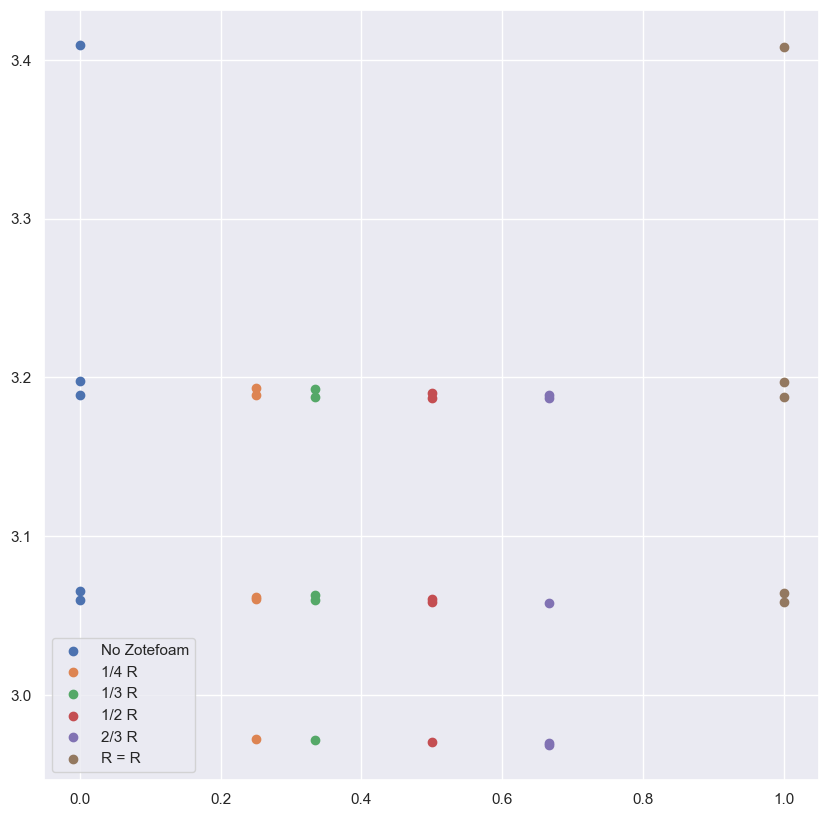

In [540]:
plt.figure(figsize=(10,10))
plt.scatter(radius_column_x_5[0], top_Qs_peaks_list[0]['Frequency (GHz)'], label = 'No Zotefoam')
plt.scatter(radius_column_x_5[1], top_Qs_peaks_list[1]['Frequency (GHz)'], label = '1/4 R')
plt.scatter(radius_column_x_5[2], top_Qs_peaks_list[2]['Frequency (GHz)'], label = '1/3 R')
plt.scatter(radius_column_x_5[3], top_Qs_peaks_list[3]['Frequency (GHz)'], label = '1/2 R')
plt.scatter(radius_column_x_5[4], top_Qs_peaks_list[4]['Frequency (GHz)'], label = '2/3 R')
plt.scatter(radius_column_x_5[5], top_Qs_peaks_list[5]['Frequency (GHz)'], label = 'R = R')
plt.legend()

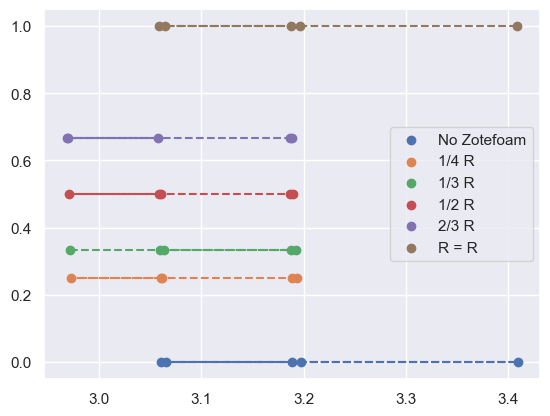

In [539]:
plt.scatter(top_Qs_peaks_list[0]['Frequency (GHz)'], radius_column_x_5[0], label = 'No Zotefoam')
plt.plot(top_Qs_peaks_list[0]['Frequency (GHz)'], radius_column_x_5[0], ls='dashed')

plt.scatter(top_Qs_peaks_list[1]['Frequency (GHz)'], radius_column_x_5[1], label = '1/4 R')
plt.plot(top_Qs_peaks_list[1]['Frequency (GHz)'], radius_column_x_5[1], ls='dashed')

plt.scatter(top_Qs_peaks_list[2]['Frequency (GHz)'], radius_column_x_5[2], label = '1/3 R')
plt.plot(top_Qs_peaks_list[2]['Frequency (GHz)'], radius_column_x_5[2], ls='dashed')

plt.scatter(top_Qs_peaks_list[3]['Frequency (GHz)'], radius_column_x_5[3], label = '1/2 R')
plt.plot(top_Qs_peaks_list[3]['Frequency (GHz)'], radius_column_x_5[3], ls='dashed')

plt.scatter(top_Qs_peaks_list[4]['Frequency (GHz)'], radius_column_x_5[4], label = '2/3 R')
plt.plot(top_Qs_peaks_list[4]['Frequency (GHz)'], radius_column_x_5[4], ls='dashed')

plt.scatter(top_Qs_peaks_list[5]['Frequency (GHz)'], radius_column_x_5[5], label = 'R = R')
plt.plot(top_Qs_peaks_list[5]['Frequency (GHz)'], radius_column_x_5[5], ls='dashed')
plt.legend()

In [517]:
radius_column_full

[0, 0.25, 0.3333333333333333, 0.5, 0.6666666666666666, 1]

In [ ]:
plt.figure()
plt.plot()

#### ^ Zotefoam bringing out TM mode?? 

In [361]:
alumina_peaks_Qmax['Frequency (GHz)'].iloc[0]

3.0656085813880583

In [437]:
radius_column_wfull = [0, 0.25, 0.3333333333333333, 0.5, 0.6666666666666666, 1]

In [431]:
Q_maxes_list = np.array([alumina_peaks_Qmax['Frequency (GHz)'].iloc[0], 
                quarter_R_peaks_Qmax['Frequency (GHz)'].iloc[0], 
                third_R_peaks_Qmax['Frequency (GHz)'].iloc[0], 
                half_R_peaks_Qmax['Frequency (GHz)'].iloc[0], 
                twothirds_R_peaks_Qmax['Frequency (GHz)'].iloc[0], 
                full_R_peaks_Qmax['Frequency (GHz)'].iloc[0]])

Q_maxes_list

array([3.06560858, 3.19325069, 2.97167333, 3.18694908, 3.1890446 ,
       3.40840359])

In [438]:
Q_maxes = pd.DataFrame([radius_column_wfull, Q_maxes_list])

In [439]:
Q_maxes

,0,1,2,3,4,5
0,0.000000,0.250000,0.333333,0.500000,0.666667,1.000000
1,3.065609,3.193251,2.971673,3.186949,3.189045,3.408404


Text(0.5, 1.0, 'Freq Location of Lowest Loss')

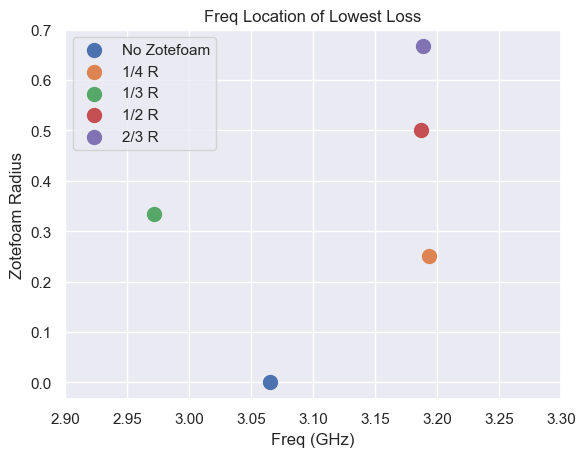

In [440]:
plt.scatter(Q_maxes.iloc[1,0], Q_maxes.iloc[0,0], label = 'No Zotefoam', s = 100)

plt.scatter(Q_maxes.iloc[1,1], Q_maxes.iloc[0,1], label = '1/4 R', s = 100)

plt.scatter(Q_maxes.iloc[1,2], Q_maxes.iloc[0,2], label = '1/3 R', s = 100)

plt.scatter(Q_maxes.iloc[1,3], Q_maxes.iloc[0,3], label = '1/2 R', s = 100)

plt.scatter(Q_maxes.iloc[1,4], Q_maxes.iloc[0,4], label = '2/3 R', s = 100)

plt.legend()
plt.xlim(2.9, 3.3)
plt.xlabel('Freq (GHz)')
plt.ylabel('Zotefoam Radius')
plt.title('Freq Location of Lowest Loss')

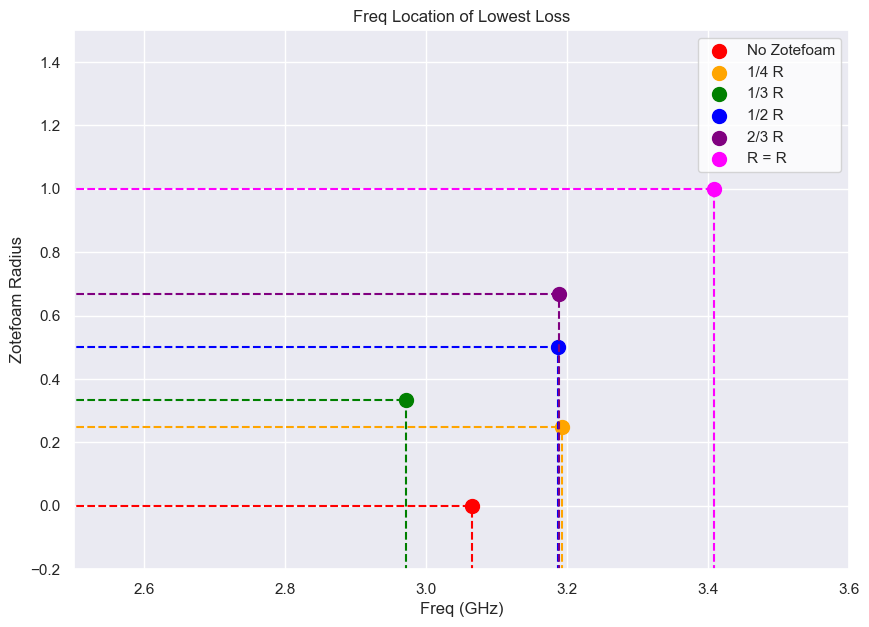

In [445]:
plt.figure(figsize = (10, 7))


plt.scatter(Q_maxes.iloc[1,0], Q_maxes.iloc[0,0], label='No Zotefoam', s=100, color = 'red')
plt.vlines(Q_maxes.iloc[1,0], ymin=-1, ymax=Q_maxes.iloc[0,0], linestyle='dashed', color = 'red')
plt.hlines(Q_maxes.iloc[0,0], xmin=0, xmax=Q_maxes.iloc[1,0], linestyle='dashed', color='red')

plt.scatter(Q_maxes.iloc[1,1], Q_maxes.iloc[0,1], label='1/4 R', s=100, color = 'orange')
plt.vlines(Q_maxes.iloc[1,1], ymin=-1, ymax=Q_maxes.iloc[0,1], linestyle='dashed', color='orange')
plt.hlines(Q_maxes.iloc[0,1], xmin=0, xmax=Q_maxes.iloc[1,1], linestyle='dashed', color='orange')

plt.scatter(Q_maxes.iloc[1,2], Q_maxes.iloc[0,2], label='1/3 R', s=100, color = 'green')
plt.vlines(Q_maxes.iloc[1,2], ymin=-1, ymax=Q_maxes.iloc[0,2], linestyle='dashed', color='green')
plt.hlines(Q_maxes.iloc[0,2], xmin=0, xmax=Q_maxes.iloc[1,2], linestyle='dashed', color='green')

plt.scatter(Q_maxes.iloc[1,3], Q_maxes.iloc[0,3], label='1/2 R', s=100, color = 'blue')
plt.vlines(Q_maxes.iloc[1,3], ymin=-1, ymax=Q_maxes.iloc[0,3], linestyle='dashed', color='blue')
plt.hlines(Q_maxes.iloc[0,3], xmin=0, xmax=Q_maxes.iloc[1,3], linestyle='dashed', color='blue')

plt.scatter(Q_maxes.iloc[1,4], Q_maxes.iloc[0,4], label='2/3 R', s=100, color = 'purple')
plt.vlines(Q_maxes.iloc[1,4], ymin=-1, ymax=Q_maxes.iloc[0,4], linestyle='dashed', color='purple')
plt.hlines(Q_maxes.iloc[0,4], xmin=0, xmax=Q_maxes.iloc[1,4], linestyle='dashed', color='purple')

plt.scatter(Q_maxes.iloc[1,5], Q_maxes.iloc[0,5], label='R = R', s=100, color = 'magenta')
plt.vlines(Q_maxes.iloc[1,5], ymin=-1, ymax=Q_maxes.iloc[0,5], linestyle='dashed', color='magenta')
plt.hlines(Q_maxes.iloc[0,5], xmin=0, xmax=Q_maxes.iloc[1,5], linestyle='dashed', color='magenta')



plt.legend(facecolor='white')
plt.xlim(2.5, 3.6)
plt.ylim(-0.2, 1.5)
plt.xlabel('Freq (GHz)')
plt.ylabel('Zotefoam Radius')
plt.title('Freq Location of Lowest Loss')
plt.show()

In [408]:
print(np.average(alumina_peaks['Quality factor (1)']))
print(np.average(quarter_R_Qpeaks['Quality factor (1)']))
print(np.average(third_R_Qpeaks['Quality factor (1)']))
print(np.average(half_R_Qpeaks['Quality factor (1)']))
print(np.average(twothirds_R_Qpeaks['Quality factor (1)']))
print(np.average(full_R_Qpeaks['Quality factor (1)']))

9839.21690687665
21130.505161527883
22875.58645639932
25812.596336504223
26253.97013672282
9954.683183720785


In [410]:
Q_peak_averages = np.array([9839.21690687665, 21130.505161527883, 22875.58645639932, 25812.596336504223, 
                            26253.97013672282, 9954.683183720785])

Q_averages = np.array([np.average(just_alumina['Quality factor (1)']), 
                       np.average(quarter_R['Quality factor (1)']), 
                       np.average(third_R['Quality factor (1)']), 
                       np.average(half_R['Quality factor (1)']), 
                       np.average(twothirds_R['Quality factor (1)']), 
                       np.average(full_R['Quality factor (1)'])])

full_R_array = np.array([0, 0.25, 0.3333333333333333, 0.5, 0.6666666666666666, 1])



Text(0, 0.5, 'Q')

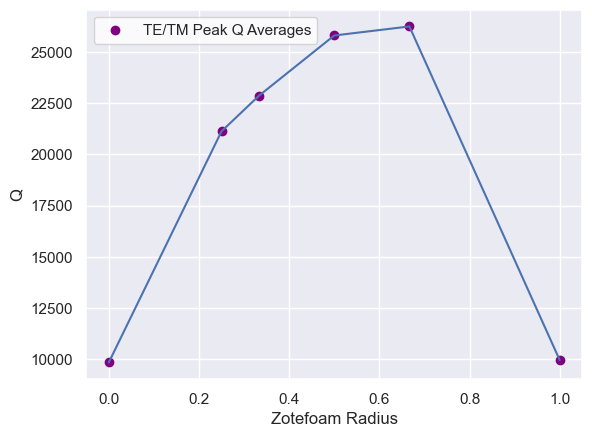

In [511]:
plt.plot(full_R_array, Q_peak_averages)
plt.scatter(full_R_array, Q_peak_averages, label = 'TE/TM Peak Q Averages', color='purple')
plt.legend(facecolor='white')
plt.xlabel('Zotefoam Radius')
plt.ylabel('Q')

Text(0, 0.5, 'Q')

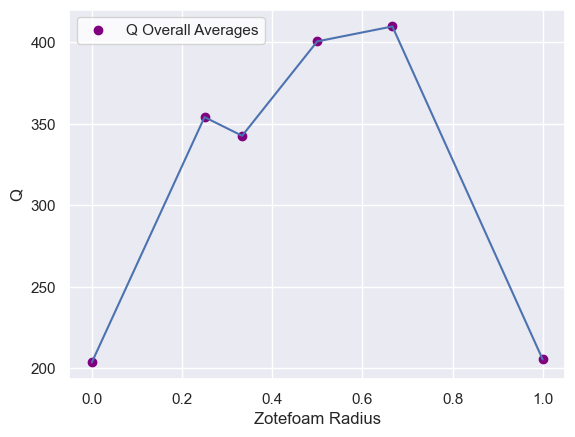

In [512]:
plt.plot(full_R_array, Q_averages)
plt.scatter(full_R_array, Q_averages, label = 'Q Overall Averages', color='purple')
plt.legend(facecolor='white')
plt.xlabel('Zotefoam Radius')
plt.ylabel('Q')

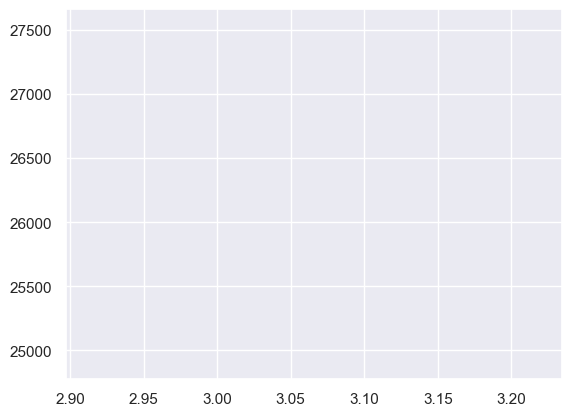

In [ ]:
# plt.plot(alumina_peaks_Qmax['Frequency (GHz)'], 
#          alumina_peaks_Qmax['Quality factor (1)'], 
#          label = 'No Zotefoam')

# plt.plot(quarter_R_peaks_Qmax['Frequency (GHz)'], 
#          quarter_R_peaks_Qmax['Quality factor (1)'], 
#          label = '1/4 R')

# plt.plot(third_R_peaks_Qmax['Frequency (GHz)'], 
#          third_R_peaks_Qmax['Quality factor (1)'], 
#          label = '1/3 R')

# plt.plot(half_R_peaks_Qmax['Frequency (GHz)'], 
#          half_R_peaks_Qmax['Quality factor (1)'], 
#          label = '1/2 R')

# plt.plot(twothirds_R_peaks_Qmax['Frequency (GHz)'], 
#          twothirds_R_peaks_Qmax['Quality factor (1)'], 
#          label = '2/3 R')

In [498]:
max_Qs = [max(alumina_peaks['Quality factor (1)']), 
          max(quarter_R_Qpeaks['Quality factor (1)']), 
          max(third_R_Qpeaks['Quality factor (1)']), 
          max(half_R_Qpeaks['Quality factor (1)']), 
          max(twothirds_R_Qpeaks['Quality factor (1)'])]

max_Qs_full = [max(alumina_peaks['Quality factor (1)']), 
          max(quarter_R_Qpeaks['Quality factor (1)']), 
          max(third_R_Qpeaks['Quality factor (1)']), 
          max(half_R_Qpeaks['Quality factor (1)']), 
          max(twothirds_R_Qpeaks['Quality factor (1)']), 
          max(full_R_Qpeaks['Quality factor (1)'])]

In [499]:
q_fac_radius = pd.DataFrame([radius_column, max_Qs])
q_fac_radius

,0,1,2,3,4
0,0.000000,0.250000,0.333333,0.500000,0.666667
1,26220.346692,44730.151506,79424.859165,62858.287216,71824.368090


In [500]:
q_fac_radius_full = pd.DataFrame([radius_column_wfull, max_Qs_full])
q_fac_radius_full

,0,1,2,3,4,5
0,0.000000,0.250000,0.333333,0.500000,0.666667,1.000000
1,26220.346692,44730.151506,79424.859165,62858.287216,71824.368090,28536.442258


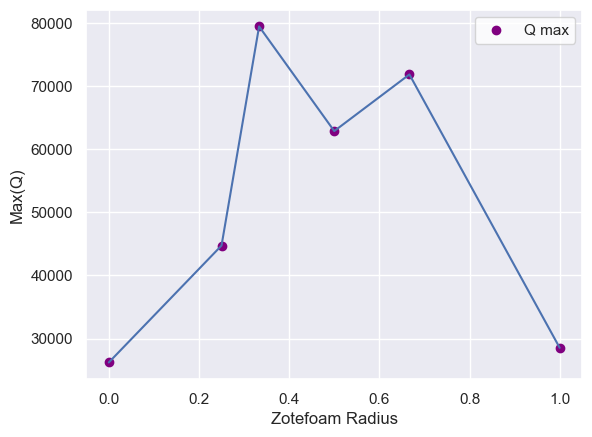

In [508]:
plt.scatter(q_fac_radius_full.iloc[0], q_fac_radius_full.iloc[1], label = 'Q max', color='purple')
plt.plot(q_fac_radius_full.iloc[0], q_fac_radius_full.iloc[1])
plt.xlabel('Zotefoam Radius')
plt.ylabel('Max(Q)')
plt.legend(facecolor='white')

## Plotting TE/TM Frequency location vs. Radius

In [314]:
resonances_df

,Radius,TE 2.5 I,TE 2.5 II,TM 2.87 I,TM 2.87 II,TE 2.97 I,TE 2.97 II,TM 3.05 I,TM 3.05 II,TE 3.19 I,TE 3.19 II,TE 3.41 I,TE 3.41 II,TM 3.45,TE 3.62 I,TE 3.62 II,TM 3.64 I,TM 3.64 II
0,0.000000,2.529201,2.530838,2.873249,2.875583,2.970204,2.976651,3.060040,3.065609,3.188710,3.197803,3.409475,3.414007,3.455147,3.627450,3.634368,3.648997,3.652435
1,0.250000,2.527270,2.528209,2.872342,2.873598,2.970540,2.971980,3.060484,3.061502,3.188800,3.193251,3.406920,3.413259,3.450945,3.625473,3.632045,3.642738,3.648805
2,0.333333,2.527084,2.527941,2.873036,2.873241,2.969833,2.971673,3.059710,3.062964,3.187907,3.192902,3.407525,3.411023,3.452663,3.624767,3.630728,3.645074,3.647750
3,0.500000,2.526884,2.527239,2.870592,2.873036,2.968589,2.970445,3.058250,3.060525,3.186949,3.189982,3.404671,3.408845,3.442302,3.619576,3.628911,3.635994,3.647687
4,0.666667,2.526875,2.527013,2.870120,2.872852,2.968526,2.969769,3.057661,3.060248,3.187040,3.189045,3.404922,3.407486,3.446101,3.620756,3.625981,3.638705,3.643501


In [315]:
resonances_df.columns

Index(['Radius', 'TE 2.5 I', 'TE 2.5 II', 'TM 2.87 I', 'TM 2.87 II',
       'TE 2.97 I', 'TE 2.97 II', 'TM 3.05 I', 'TM 3.05 II', 'TE 3.19 I',
       'TE 3.19 II', 'TE 3.41 I', 'TE 3.41 II', 'TM 3.45', 'TE 3.62 I',
       'TE 3.62 II', 'TM 3.64 I', 'TM 3.64 II'],
      dtype='object')

In [336]:
# plt.figure()
# # plt.plot(resonances_df['Radius'], resonances_df[0], label = '2.5 GHz 1')
# # plt.plot(resonances_df['Radius'], resonances_df[1], label = '2.5 GHz 2')
# # plt.plot(resonances_df['Radius'], resonances_df[2], label = '2.87 GHz 1')
# # plt.plot(resonances_df['Radius'], resonances_df[3], label = '2.87 GHz 2')
# # plt.plot(resonances_df['Radius'], resonances_df[4], label = '2.97 GHz 1')
# # plt.plot(resonances_df['Radius'], resonances_df[5], label = '2.97 GHz 2')
# # plt.plot(resonances_df['Radius'], resonances_df[6], label = '3.06 GHz 1')
# # plt.plot(resonances_df['Radius'], resonances_df[7], label = '3.06 GHz 2')
# # plt.plot(resonances_df['Radius'], resonances_df[8], label = '3.18 GHz 1')
# # plt.plot(resonances_df['Radius'], resonances_df[9], label = '3.18 GHz 2')
# # plt.plot(resonances_df['Radius'], resonances_df[10], label = '3.4 GHz 1')
# # plt.plot(resonances_df['Radius'], resonances_df[11], label = '3.4 GHz 2')
# # plt.plot(resonances_df['Radius'], resonances_df[12], label = '3.44 GHz')
# plt.plot(resonances_df['Radius'], resonances_df['TE 3.62 I'], label = '3.62 GHz 1 (TE)')
# plt.plot(resonances_df['Radius'], resonances_df['TE 3.62 II'], label = '3.62 GHz 2 (TE)')
# plt.plot(resonances_df['Radius'], resonances_df['TM 3.64 I'], label = '3.64 GHz 1 (TM)')
# plt.plot(resonances_df['Radius'], resonances_df['TM 3.64 II'], label = '3.64 GHz 2 (TM)')
# plt.xlabel('Zotefoam Contact Radius')
# plt.ylabel('Frequency Location of TE/TM mode')
# plt.title('Resonant Mode Location vs. Zotefoam Radius')
# plt.legend()




Text(0.5, 1.0, 'Resonant Mode Location vs. Zotefoam Radius')

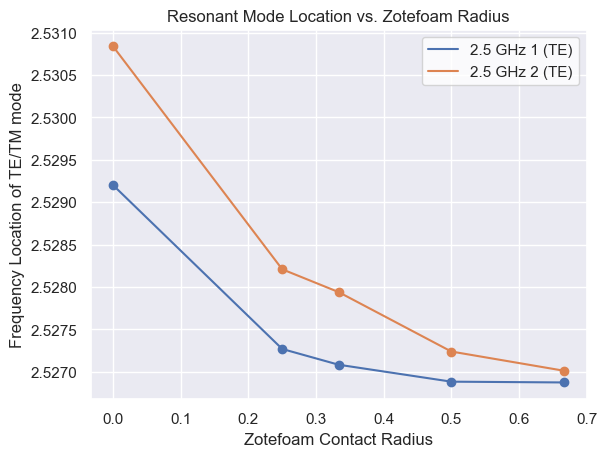

In [488]:
plt.plot(resonances_df['Radius'], resonances_df['TE 2.5 I'], label = '2.5 GHz 1 (TE)')
plt.plot(resonances_df['Radius'], resonances_df['TE 2.5 II'], label = '2.5 GHz 2 (TE)')
plt.scatter(resonances_df['Radius'], resonances_df['TE 2.5 I'])
plt.scatter(resonances_df['Radius'], resonances_df['TE 2.5 II'])
plt.legend(facecolor='white')
plt.xlabel('Zotefoam Contact Radius')
plt.ylabel('Frequency Location of TE/TM mode')
plt.title('Resonant Mode Location vs. Zotefoam Radius')

Text(0.5, 1.0, 'Resonant Mode Location vs. Zotefoam Radius')

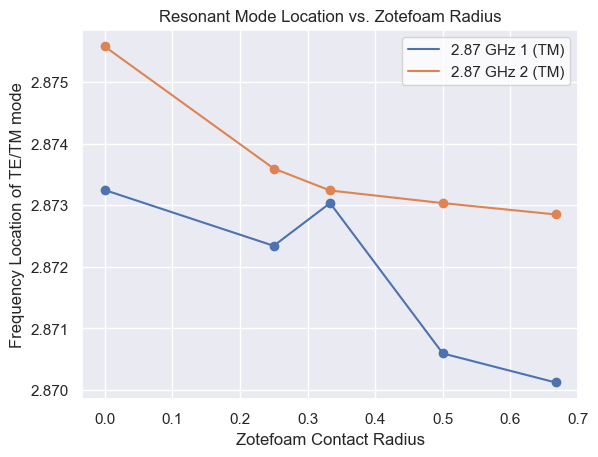

In [489]:
plt.plot(resonances_df['Radius'], resonances_df['TM 2.87 I'], label = '2.87 GHz 1 (TM)')
plt.plot(resonances_df['Radius'], resonances_df['TM 2.87 II'], label = '2.87 GHz 2 (TM)')
plt.scatter(resonances_df['Radius'], resonances_df['TM 2.87 I'])
plt.scatter(resonances_df['Radius'], resonances_df['TM 2.87 II'])

plt.legend(facecolor='white')
plt.xlabel('Zotefoam Contact Radius')
plt.ylabel('Frequency Location of TE/TM mode')
plt.title('Resonant Mode Location vs. Zotefoam Radius')

Text(0.5, 1.0, 'Resonant Mode Location vs. Zotefoam Radius')

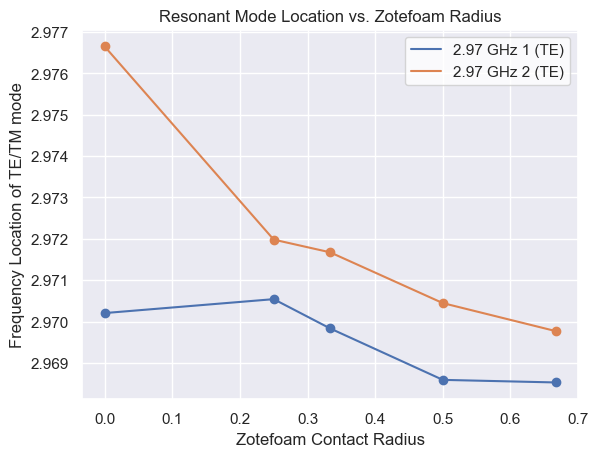

In [490]:

plt.plot(resonances_df['Radius'], resonances_df['TE 2.97 I'], label = '2.97 GHz 1 (TE)')
plt.plot(resonances_df['Radius'], resonances_df['TE 2.97 II'], label = '2.97 GHz 2 (TE)')
plt.scatter(resonances_df['Radius'], resonances_df['TE 2.97 I'])
plt.scatter(resonances_df['Radius'], resonances_df['TE 2.97 II'])
plt.legend(facecolor='white')
plt.xlabel('Zotefoam Contact Radius')
plt.ylabel('Frequency Location of TE/TM mode')
plt.title('Resonant Mode Location vs. Zotefoam Radius')

Text(0.5, 1.0, 'Resonant Mode Location vs. Zotefoam Radius')

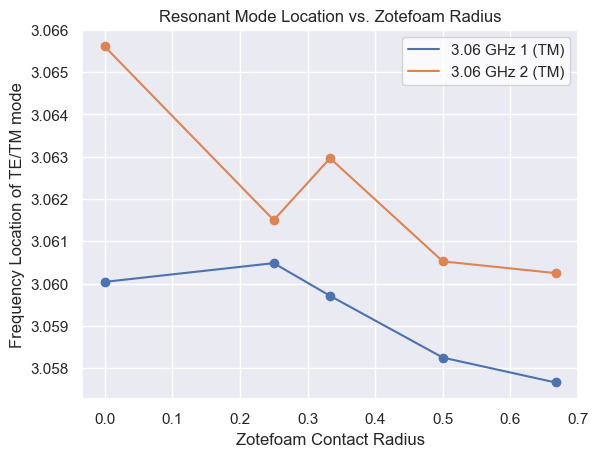

In [491]:
plt.plot(resonances_df['Radius'], resonances_df['TM 3.05 I'], label = '3.06 GHz 1 (TM)')
plt.plot(resonances_df['Radius'], resonances_df['TM 3.05 II'], label = '3.06 GHz 2 (TM)')
plt.scatter(resonances_df['Radius'], resonances_df['TM 3.05 I'])
plt.scatter(resonances_df['Radius'], resonances_df['TM 3.05 II'])
plt.legend(facecolor='white')
plt.xlabel('Zotefoam Contact Radius')
plt.ylabel('Frequency Location of TE/TM mode')
plt.title('Resonant Mode Location vs. Zotefoam Radius')

Text(0.5, 1.0, 'Resonant Mode Location vs. Zotefoam Radius')

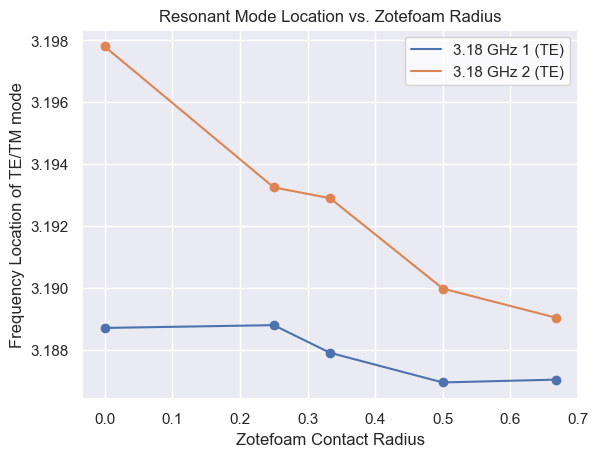

In [492]:
plt.plot(resonances_df['Radius'], resonances_df['TE 3.19 I'], label = '3.18 GHz 1 (TE)')
plt.plot(resonances_df['Radius'], resonances_df['TE 3.19 II'], label = '3.18 GHz 2 (TE)')
plt.scatter(resonances_df['Radius'], resonances_df['TE 3.19 I'])
plt.scatter(resonances_df['Radius'], resonances_df['TE 3.19 II'])
plt.legend(facecolor='white')
plt.xlabel('Zotefoam Contact Radius')
plt.ylabel('Frequency Location of TE/TM mode')
plt.title('Resonant Mode Location vs. Zotefoam Radius')

Text(0.5, 1.0, 'Resonant Mode Location vs. Zotefoam Radius')

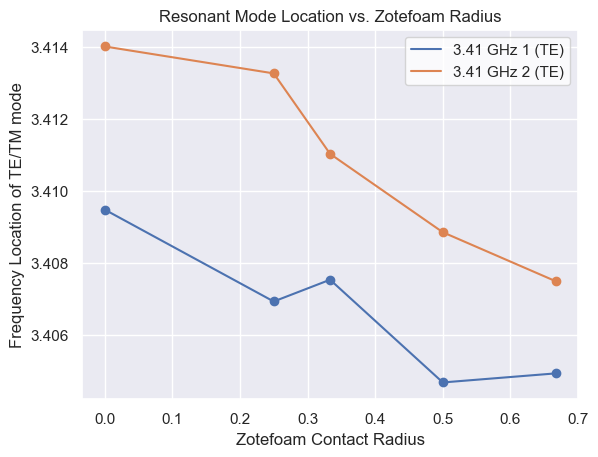

In [493]:
plt.plot(resonances_df['Radius'], resonances_df['TE 3.41 I'], label = '3.41 GHz 1 (TE)')
plt.plot(resonances_df['Radius'], resonances_df['TE 3.41 II'], label = '3.41 GHz 2 (TE)')
plt.scatter(resonances_df['Radius'], resonances_df['TE 3.41 I'])
plt.scatter(resonances_df['Radius'], resonances_df['TE 3.41 II'])
plt.legend(facecolor='white')
plt.xlabel('Zotefoam Contact Radius')
plt.ylabel('Frequency Location of TE/TM mode')
plt.title('Resonant Mode Location vs. Zotefoam Radius')

Text(0.5, 1.0, 'Resonant Mode Location vs. Zotefoam Radius')

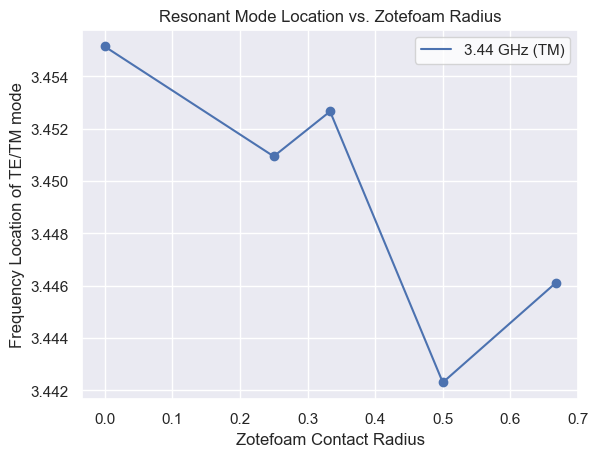

In [494]:
plt.plot(resonances_df['Radius'], resonances_df['TM 3.45'], label = '3.44 GHz (TM)')
plt.scatter(resonances_df['Radius'], resonances_df['TM 3.45'])
plt.legend(facecolor='white')
plt.xlabel('Zotefoam Contact Radius')
plt.ylabel('Frequency Location of TE/TM mode')
plt.title('Resonant Mode Location vs. Zotefoam Radius')

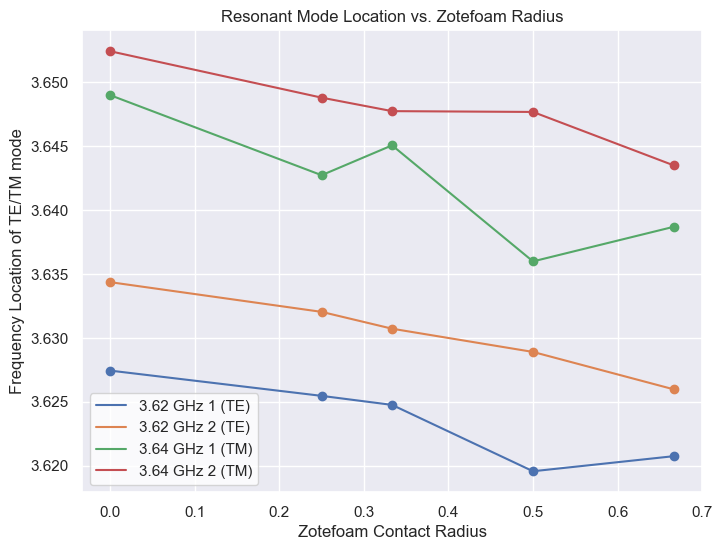

In [495]:
plt.figure(figsize = (8,6))
plt.plot(resonances_df['Radius'], resonances_df['TE 3.62 I'], label = '3.62 GHz 1 (TE)')
plt.scatter(resonances_df['Radius'], resonances_df['TE 3.62 I'])

plt.plot(resonances_df['Radius'], resonances_df['TE 3.62 II'], label = '3.62 GHz 2 (TE)')
plt.scatter(resonances_df['Radius'], resonances_df['TE 3.62 II'])

plt.plot(resonances_df['Radius'], resonances_df['TM 3.64 I'], label = '3.64 GHz 1 (TM)')
plt.scatter(resonances_df['Radius'], resonances_df['TM 3.64 I'])

plt.plot(resonances_df['Radius'], resonances_df['TM 3.64 II'], label = '3.64 GHz 2 (TM)')
plt.scatter(resonances_df['Radius'], resonances_df['TM 3.64 II'])


plt.xlabel('Zotefoam Contact Radius')
plt.ylabel('Frequency Location of TE/TM mode')
plt.title('Resonant Mode Location vs. Zotefoam Radius')
plt.legend(facecolor='white')

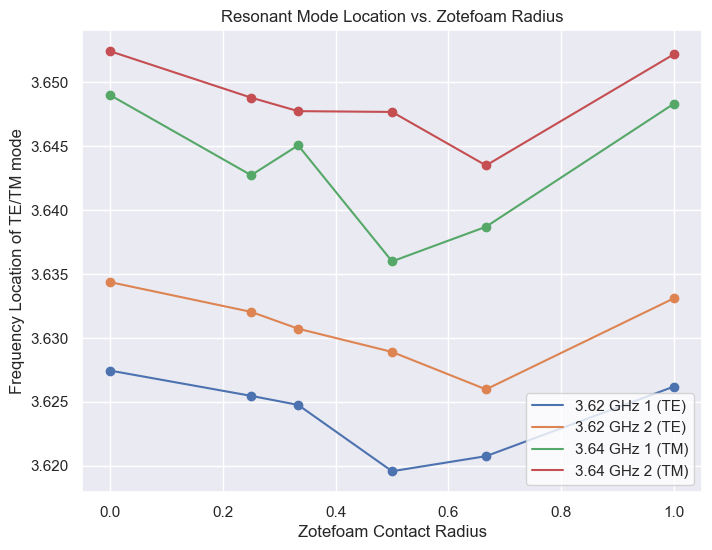

In [496]:
plt.figure(figsize = (8,6))
plt.plot(resonances_df_full['Radius'], resonances_df_full['TE 3.62 I'], label = '3.62 GHz 1 (TE)')
plt.scatter(resonances_df_full['Radius'], resonances_df_full['TE 3.62 I'])

plt.plot(resonances_df_full['Radius'], resonances_df_full['TE 3.62 II'], label = '3.62 GHz 2 (TE)')
plt.scatter(resonances_df_full['Radius'], resonances_df_full['TE 3.62 II'])

plt.plot(resonances_df_full['Radius'], resonances_df_full['TM 3.64 I'], label = '3.64 GHz 1 (TM)')
plt.scatter(resonances_df_full['Radius'], resonances_df_full['TM 3.64 I'])

plt.plot(resonances_df_full['Radius'], resonances_df_full['TM 3.64 II'], label = '3.64 GHz 2 (TM)')
plt.scatter(resonances_df_full['Radius'], resonances_df_full['TM 3.64 II'])


plt.xlabel('Zotefoam Contact Radius')
plt.ylabel('Frequency Location of TE/TM mode')
plt.title('Resonant Mode Location vs. Zotefoam Radius')
plt.legend(facecolor='white')

In [77]:
radius_column = [1/4, 1/3, 1/2, 2/3]

In [76]:
resonances_df[0]

0    2.527270
1    2.527084
2    2.526884
3    2.526875
Name: 0, dtype: float64

In [279]:
resonances_df

,Radius,TE 2.5 I,TE 2.5 II,TM 2.87 I,TM 2.87 II,TE 2.97 I,TE 2.97 II,TM 3.05 I,TM 3.05 II,TE 3.19 I,TE 3.19 II,TE 3.41 I,TE 3.41 II,TM 3.45,TE 3.62 I,TE 3.62 II,TM 3.64 I,TM 3.64 II
0,0.000000,2.529201,2.530838,2.873249,2.875583,2.970204,2.976651,3.060040,3.065609,3.188710,3.197803,3.409475,3.414007,3.455147,3.627450,3.634368,3.648997,3.652435
1,0.250000,2.527270,2.528209,2.872342,2.873598,2.970540,2.971980,3.060484,3.061502,3.188800,3.193251,3.406920,3.413259,3.450945,3.625473,3.632045,3.642738,3.648805
2,0.333333,2.527084,2.527941,2.873036,2.873241,2.969833,2.971673,3.059710,3.062964,3.187907,3.192902,3.407525,3.411023,3.452663,3.624767,3.630728,3.645074,3.647750
3,0.500000,2.526884,2.527239,2.870592,2.873036,2.968589,2.970445,3.058250,3.060525,3.186949,3.189982,3.404671,3.408845,3.442302,3.619576,3.628911,3.635994,3.647687
4,0.666667,2.526875,2.527013,2.870120,2.872852,2.968526,2.969769,3.057661,3.060248,3.187040,3.189045,3.404922,3.407486,3.446101,3.620756,3.625981,3.638705,3.643501


In [62]:
third_R_peakfreqs

0     2.527084
1     2.527941
2     2.873036
3     2.873241
4     2.969833
5     2.971673
6     3.059710
7     3.062964
8     3.187907
9     3.192902
10    3.407525
11    3.411023
12    3.452663
13    3.624767
14    3.630728
15    3.645074
16    3.647750
Name: Frequency (GHz), dtype: float64

In [63]:
half_R_peakfreqs

0     2.526884
1     2.527239
2     2.870592
3     2.873036
4     2.968589
5     2.970445
6     3.058250
7     3.060525
8     3.186949
9     3.189982
10    3.404671
11    3.408845
12    3.442302
13    3.619576
14    3.628911
15    3.635994
16    3.647687
Name: Frequency (GHz), dtype: float64

In [61]:
twothirds_R_peakfreqs

0     2.526875
1     2.527013
2     2.870120
3     2.872852
4     2.968526
5     2.969769
6     3.057661
7     3.060248
8     3.187040
9     3.189045
10    3.404922
11    3.407486
12    3.446101
13    3.620756
14    3.625981
15    3.638705
16    3.643501
17    3.837943
Name: Frequency (GHz), dtype: float64

In [60]:
third_R_peakfreqs

0     2.527084
1     2.527941
2     2.873036
3     2.873241
4     2.969833
5     2.971673
6     3.059710
7     3.062964
8     3.187907
9     3.192902
10    3.407525
11    3.411023
12    3.452663
13    3.624767
14    3.630728
15    3.645074
16    3.647750
Name: Frequency (GHz), dtype: float64

In [10]:
Q_peaks, _ = spg.find_peaks(quarter_R['Quality factor (1)'])
Q_peaks_df = quarter_R.iloc[Q_peaks].sort_values(['Quality factor (1)'], ascending=False)
top_peaks = Q_peaks_df.iloc[0:30]
top_peaks

,% r_zotefoam (m),search_freq (Hz),Eigenfrequency (GHz),Frequency (GHz),Quality factor (1)
477,0.019056,3.000000e+09,3.193251+0.000036j,3.193251,44730.151506
475,0.019056,3.000000e+09,3.188800+0.000036j,3.188800,44358.347161
420,0.019056,3.000000e+09,3.061502+0.000039j,3.061502,39522.718314
330,0.019056,3.000000e+09,2.971980+0.000039j,2.971980,38121.126055
501,0.019056,3.500000e+09,3.406920+0.000079j,3.406920,21533.539236
706,0.019056,3.500000e+09,3.632045+0.000086j,3.632045,21089.975647
536,0.019056,3.500000e+09,3.450945+0.000093j,3.450945,18504.550968
522,0.019056,3.500000e+09,3.443743+0.000104j,3.443743,16498.940826
503,0.019056,3.500000e+09,3.413259+0.000113j,3.413259,15082.659460
712,0.019056,3.500000e+09,3.648805+0.000125j,3.648805,14651.433851


In [9]:
Q_peaks, _ = spg.find_peaks(third_R['Quality factor (1)'])
Q_peaks_df = third_R.iloc[Q_peaks].sort_values(['Quality factor (1)'], ascending=False)
top_peaks = Q_peaks_df.iloc[0:10]
top_peaks

,% r_zotefoam (m),search_freq (Hz),Eigenfrequency (GHz),Frequency (GHz),Quality factor (1)
2009,0.025408,3.000000e+09,2.971673+0.000019j,2.971673,79424.859165
2155,0.025408,3.000000e+09,3.187907+0.000029j,3.187907,54614.716230
2157,0.025408,3.000000e+09,3.192902+0.000033j,3.192902,48748.839563
2102,0.025408,3.000000e+09,3.062964+0.000042j,3.062964,36821.935744
2098,0.025408,3.000000e+09,3.059710+0.000046j,3.059710,33547.629753
2182,0.025408,3.500000e+09,3.411023+0.000084j,3.411023,20305.070604
2391,0.025408,3.500000e+09,3.645074+0.000146j,3.645074,12481.142565
1811,0.025408,2.500000e+09,2.527084+0.000109j,2.527084,11636.646056
2383,0.025408,3.500000e+09,3.624767+0.000161j,3.624767,11235.013442
1925,0.025408,3.000000e+09,2.873241+0.000145j,2.873241,9887.118002


In [18]:
quarter_R_reduced, quarter_R_peaks = uf.find_plot_Q_peaks(quarter_R, n_peaks=20, plot=False)
third_R_reduced, third_R_peaks = uf.find_plot_Q_peaks(third_R, n_peaks=20, plot=False)
half_R_reduced, half_R_peaks = uf.find_plot_Q_peaks(half_R, n_peaks=20, plot=False)
twothirds_R_reduced, twothirds_R_peaks = uf.find_plot_Q_peaks(twothirds_R, n_peaks=20, plot=False)
full_R_reduced, full_R_peaks = uf.find_plot_Q_peaks(full_R, n_peaks=20, plot=False)

/Users/leayamashiro/whispering_gallery_MAIN/calibrated/analysis/useful_functions.py:165: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Q_freq_data['Freq rounded'] = Q_freq_data['Frequency (GHz)'].round(5)
/Users/leayamashiro/whispering_gallery_MAIN/calibrated/analysis/useful_functions.py:165: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Q_freq_data['Freq rounded'] = Q_freq_data['Frequency (GHz)'].round(5)
/Users/leayamashiro/whispering_gallery_MAIN/calibrated/analysis/useful_functions.py:165: SettingWithCo

In [15]:
quarter_R_peaks

,index,cf,freqs,Q
0,477,3.000000e+09,3.193251,44730.151506
1,475,3.000000e+09,3.188800,44358.347161
2,420,3.000000e+09,3.061502,39522.718314
3,330,3.000000e+09,2.971980,38121.126055
4,501,3.500000e+09,3.406920,21533.539236
5,706,3.500000e+09,3.632045,21089.975647
6,536,3.500000e+09,3.450945,18504.550968
7,522,3.500000e+09,3.443743,16498.940826
8,503,3.500000e+09,3.413259,15082.659460
9,712,3.500000e+09,3.648805,14651.433851


In [14]:
full_R_peaks

,index,cf,freqs,Q
0,7222,3.500000e+09,3.408404,28536.442258
1,7143,3.000000e+09,3.064110,26208.375730
2,7138,3.000000e+09,3.058627,24522.532638
3,7196,3.000000e+09,3.187654,16753.080983
4,7198,3.000000e+09,3.196782,14903.051734
5,6853,2.500000e+09,2.529899,11047.639242
6,7225,3.500000e+09,3.412799,10825.403430
7,7057,3.000000e+09,2.975817,9595.058471
8,6962,3.000000e+09,2.871407,9580.564384
9,6964,3.000000e+09,2.873661,9187.540412


In [19]:
quarter_R_peaks_ND = uf.find_plot_Q_peaks_no_dup(quarter_R, n_peaks=20, plot=False)


third_R_reduced, third_R_peaks = uf.find_plot_Q_peaks_no_dup(third_R, n_peaks=20, plot=False)
half_R_reduced, half_R_peaks = uf.find_plot_Q_peaks_no_dup(half_R, n_peaks=20, plot=False)
twothirds_R_reduced, twothirds_R_peaks = uf.find_plot_Q_peaks_no_dup(twothirds_R, n_peaks=20, plot=False)
full_R_reduced, full_R_peaks = uf.find_plot_Q_peaks_no_dup(full_R, n_peaks=20, plot=False)

KeyError: "None of [Index([   2,    6,    9,   11,   13,   16,   18,   22,   27,   31,\n       ...\n       1647, 1652, 1654, 1660, 1662, 1666, 1669, 1673, 1676, 1678],\n      dtype='int64', length=553)] are in the [index]"

In [16]:
quarter_R_peaks_ND == quarter_R_peaks

,index,cf,freqs,Q
0,True,True,True,True
1,True,True,True,True
2,True,True,True,True
3,True,True,True,True
4,True,True,True,True
5,True,True,True,True
6,True,True,True,True
7,True,True,True,True
8,True,True,True,True
9,True,True,True,True


In [12]:
quarter_R_peaks

,index,cf,freqs,Q
0,477,3.000000e+09,3.193251,44730.151506
1,475,3.000000e+09,3.188800,44358.347161
2,420,3.000000e+09,3.061502,39522.718314
3,330,3.000000e+09,2.971980,38121.126055
4,501,3.500000e+09,3.406920,21533.539236
5,706,3.500000e+09,3.632045,21089.975647
6,536,3.500000e+09,3.450945,18504.550968
7,522,3.500000e+09,3.443743,16498.940826
8,503,3.500000e+09,3.413259,15082.659460
9,712,3.500000e+09,3.648805,14651.433851


In [ ]:

print(np.average(quarter_R_peaks['Q']))
print(np.average(third_R_peaks['Q']))
print(np.average(half_R_peaks['Q']))
print(np.average(twothirds_R_peaks['Q']))
print(np.average(full_R_peaks['Q']))

12941.347688055344
18427.980984952046
18871.383814844878
22785.193263493205
10105.338172002557


In [407]:
quarter_R_Qpeaks

,% r_zotefoam (m),search_freq (Hz),Eigenfrequency (GHz),Frequency (GHz),Quality factor (1)
0,0.019056,2.500000e+09,2.527270+0.000110j,2.527270,11538.548092
1,0.019056,2.500000e+09,2.528209+0.000110j,2.528209,11528.926570
2,0.019056,3.000000e+09,2.872342+0.000133j,2.872342,10784.353903
3,0.019056,3.000000e+09,2.873598+0.000137j,2.873598,10523.027438
4,0.019056,3.000000e+09,2.970540+0.000134j,2.970540,11045.628029
5,0.019056,3.000000e+09,2.971980+0.000039j,2.971980,38121.126055
6,0.019056,3.000000e+09,3.060484+0.000044j,3.060484,34700.068670
7,0.019056,3.000000e+09,3.061502+0.000039j,3.061502,39522.718314
8,0.019056,3.000000e+09,3.188800+0.000036j,3.188800,44358.347161
9,0.019056,3.000000e+09,3.193251+0.000036j,3.193251,44730.151506


In [405]:
quarter_R_peaks

,index,cf,freqs,Q
0,477,3.000000e+09,3.193251,44730.151506
1,475,3.000000e+09,3.188800,44358.347161
2,420,3.000000e+09,3.061502,39522.718314
3,330,3.000000e+09,2.971980,38121.126055
4,501,3.500000e+09,3.406920,21533.539236
5,706,3.500000e+09,3.632045,21089.975647
6,536,3.500000e+09,3.450945,18504.550968
7,522,3.500000e+09,3.443743,16498.940826
8,503,3.500000e+09,3.413259,15082.659460
9,712,3.500000e+09,3.648805,14651.433851


In [26]:
print(np.average(quarter_R_reduced['Quality factor (1)']))
print(np.average(third_R_reduced['Quality factor (1)']))
print(np.average(half_R_reduced['Quality factor (1)']))
print(np.average(twothirds_R_reduced['Quality factor (1)']))
print(np.average(full_R_reduced['Quality factor (1)']))

354.1046149970018
342.6294751722738
400.569083303788
409.73413703663505
205.35837642142445


Okay yeah maybe this is interesting. But also there could be things about the way that I entered in the Zotefoam parameters that aren't perfect, or different. And the Zotefoam interference could be frequency dependent... 

Also wonder for the peak averages what happens when I take a larger sample of "peaks"...

Also, thinking about Jackson's equation, since there is a slight index of refraction, having some not completely permittive material physically up against the alumina could be helping further contain the fields, which is why there might be this sweet spot at 2/3 R. Because that's about where the best lobes happen in the whispering gallery modes. So it would make sense that for the r = R, it drops back down. Interesting! 

In [14]:
quarter_R_peaks

,index,cf,freqs,Q
0,477,3.000000e+09,3.193251,44730.151506
1,475,3.000000e+09,3.188800,44358.347161
2,420,3.000000e+09,3.061502,39522.718314
3,330,3.000000e+09,2.971980,38121.126055
4,501,3.500000e+09,3.406920,21533.539236
5,706,3.500000e+09,3.632045,21089.975647
6,536,3.500000e+09,3.450945,18504.550968
7,522,3.500000e+09,3.443743,16498.940826
8,503,3.500000e+09,3.413259,15082.659460
9,712,3.500000e+09,3.648805,14651.433851


In [8]:
quarter_R

,% r_zotefoam (m),search_freq (Hz),Eigenfrequency (GHz),Frequency (GHz),Quality factor (1),Freq rounded
0,0.019056,2.500000e+09,2.300990+0.120102j,2.300990,9.579283,2.30099
1,0.019056,2.500000e+09,2.301470+0.118395j,2.301470,9.719449,2.30147
2,0.019056,2.500000e+09,2.302208+0.000443j,2.302208,2598.764480,2.30221
3,0.019056,2.500000e+09,2.302459+0.000443j,2.302459,2595.928723,2.30246
4,0.019056,2.500000e+09,2.315833+0.090437j,2.315833,12.803622,2.31583
...,...,...,...,...,...,...
1675,0.019056,5.500000e+09,5.604099+0.005926j,5.604099,472.842192,5.60410
1676,0.019056,5.500000e+09,5.608654+0.039165j,5.608654,71.602872,5.60865
1677,0.019056,5.500000e+09,5.610166+0.008512j,5.610166,329.560179,5.61017
1678,0.019056,5.500000e+09,5.611141+0.005523j,5.611141,508.020939,5.61114


In [9]:
quarter_R_reduced

,% r_zotefoam (m),search_freq (Hz),Eigenfrequency (GHz),Frequency (GHz),Quality factor (1),Freq rounded
0,0.019056,2.500000e+09,2.300990+0.120102j,2.300990,9.579283,2.30099
1,0.019056,2.500000e+09,2.301470+0.118395j,2.301470,9.719449,2.30147
2,0.019056,2.500000e+09,2.302208+0.000443j,2.302208,2598.764480,2.30221
3,0.019056,2.500000e+09,2.302459+0.000443j,2.302459,2595.928723,2.30246
4,0.019056,2.500000e+09,2.315833+0.090437j,2.315833,12.803622,2.31583
...,...,...,...,...,...,...
1675,0.019056,5.500000e+09,5.604099+0.005926j,5.604099,472.842192,5.60410
1676,0.019056,5.500000e+09,5.608654+0.039165j,5.608654,71.602872,5.60865
1677,0.019056,5.500000e+09,5.610166+0.008512j,5.610166,329.560179,5.61017
1678,0.019056,5.500000e+09,5.611141+0.005523j,5.611141,508.020939,5.61114


In [11]:
quarter_R_reduced, quarter_R_peaks = uf.find_plot_Q_peaks(quarter_R, n_peaks=30, plot=False)
third_R_reduced, third_R_peaks = uf.find_plot_Q_peaks(third_R, n_peaks=20, plot=False)
half_R_reduced, half_R_peaks = uf.find_plot_Q_peaks(half_R, n_peaks=20, plot=False)
twothirds_R_reduced, twothirds_R_peaks = uf.find_plot_Q_peaks(twothirds_R, n_peaks=20, plot=False)
full_R_reduced, full_R_peaks = uf.find_plot_Q_peaks(full_R, n_peaks=20, plot=False)

/Users/leayamashiro/whispering_gallery_MAIN/calibrated/analysis/useful_functions.py:165: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Q_freq_data['Freq rounded'] = Q_freq_data['Frequency (GHz)'].round(5)
/Users/leayamashiro/whispering_gallery_MAIN/calibrated/analysis/useful_functions.py:165: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Q_freq_data['Freq rounded'] = Q_freq_data['Frequency (GHz)'].round(5)
/Users/leayamashiro/whispering_gallery_MAIN/calibrated/analysis/useful_functions.py:165: SettingWithCo

In [ ]:
print(np.average())

In [12]:
quarter_R_reduced[(quarter_R_reduced['Frequency (GHz)']>2.8)&(quarter_R_reduced['Frequency (GHz)']<2.92)]

,% r_zotefoam (m),search_freq (Hz),Eigenfrequency (GHz),Frequency (GHz),Quality factor (1),Freq rounded
240,0.019056,3.000000e+09,2.803900+0.013158j,2.803900,106.545333,2.80390
241,0.019056,3.000000e+09,2.805139+0.013190j,2.805139,106.334119,2.80514
242,0.019056,3.000000e+09,2.867643+0.035868j,2.867643,39.974946,2.86764
243,0.019056,3.000000e+09,2.867964+0.035764j,2.867964,40.096126,2.86796
244,0.019056,3.000000e+09,2.872342+0.000133j,2.872342,10784.353903,2.87234
245,0.019056,3.000000e+09,2.873598+0.000137j,2.873598,10523.027438,2.87360
246,0.019056,3.000000e+09,2.896572+0.137128j,2.896572,10.561562,2.89657
247,0.019056,3.000000e+09,2.896816+0.138160j,2.896816,10.483580,2.89682
248,0.019056,3.000000e+09,2.897653+0.026825j,2.897653,54.010366,2.89765
249,0.019056,3.000000e+09,2.897928+0.137725j,2.897928,10.520691,2.89793


#### This is as of EOD July 3, 2025. Have a new plan ^^

In [99]:
quarter_R_reduced['Frequency (GHz)'].iloc[244]

2.872341637841935

In [95]:
quarter_R_peaks.sort_values(['freqs'], ascending=True).to_csv('Q_data/quarter_R_peaks.csv', index=False)
third_R_peaks.sort_values(['freqs'], ascending=True).to_csv('Q_data/third_R_peaks.csv', index=False)
half_R_peaks.sort_values(['freqs'], ascending=True).to_csv('Q_data/half_R_peaks.csv', index=False)
twothirds_R_peaks.sort_values(['freqs'], ascending=True).to_csv('Q_data/twothirds_R_peaks.csv', index=False)
full_R_peaks.sort_values(['freqs'], ascending=True).to_csv('Q_data/full_R_peaks.csv', index=False)


In [ ]:
third_R_peaks.sort_values(['freqs'], ascending=True)

,index,cf,freqs,Q
23,1682,2.500000e+09,2.301967,2607.983638
7,1811,2.500000e+09,2.527084,11636.646056
27,1906,2.500000e+09,2.687035,2330.679610
28,1909,2.500000e+09,2.688709,2314.850600
9,1925,3.000000e+09,2.873241,9887.118002
11,2005,3.000000e+09,2.969833,8013.885757
0,2009,3.000000e+09,2.971673,79424.859165
4,2098,3.000000e+09,3.059710,33547.629753
3,2102,3.000000e+09,3.062964,36821.935744
1,2155,3.000000e+09,3.187907,54614.716230


1680 rows per radius of zotefoam

In [66]:
quarter_R = alumina_zotefoam[alumina_zotefoam['% r_zotefoam (m)'].round(6)==0.019056]
third_R = alumina_zotefoam[alumina_zotefoam['% r_zotefoam (m)'].round(6)==0.025408]
half_R = alumina_zotefoam[alumina_zotefoam['% r_zotefoam (m)'].round(7)==0.0381125]
twothirds_R = alumina_zotefoam[alumina_zotefoam['% r_zotefoam (m)'].round(6)==0.050817]
full_R = alumina_zotefoam[alumina_zotefoam['% r_zotefoam (m)'].round(6)==0.076225]

Plan: get data into a situation where I can plot radius vs. frequency for one peak... or for multiple

(2.5, 4.0)

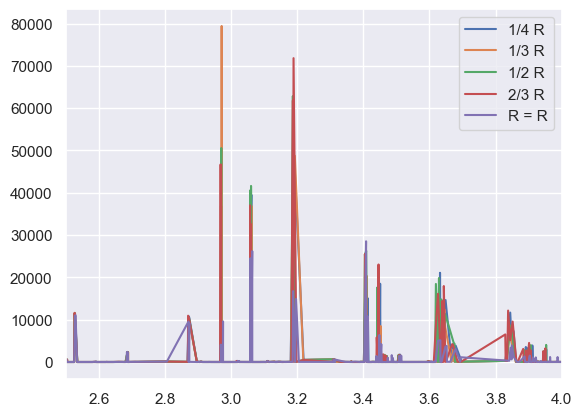

In [67]:
plt.plot(quarter_R['Frequency (GHz)'], quarter_R['Quality factor (1)'], label = '1/4 R')
plt.plot(third_R['Frequency (GHz)'], third_R['Quality factor (1)'], label = '1/3 R')
plt.plot(half_R['Frequency (GHz)'], half_R['Quality factor (1)'], label = '1/2 R')
plt.plot(twothirds_R['Frequency (GHz)'], twothirds_R['Quality factor (1)'], label = '2/3 R')
plt.plot(full_R['Frequency (GHz)'], full_R['Quality factor (1)'], label = 'R = R')
plt.legend()

plt.xlim(2.5, 4.0)

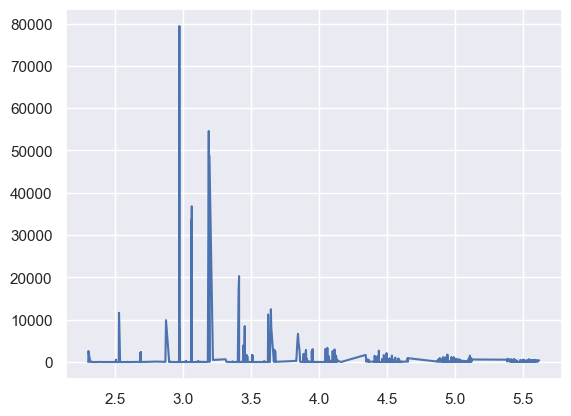

In [68]:
plt.plot(third_R['Frequency (GHz)'], third_R['Quality factor (1)'], label = 'R = R')

In [69]:
quarter_R_peaks

,index,cf,freqs,Q
0,477,3.000000e+09,3.193251,44730.151506
1,475,3.000000e+09,3.188800,44358.347161
2,420,3.000000e+09,3.061502,39522.718314
3,330,3.000000e+09,2.971980,38121.126055
4,501,3.500000e+09,3.406920,21533.539236
5,706,3.500000e+09,3.632045,21089.975647
6,536,3.500000e+09,3.450945,18504.550968
7,522,3.500000e+09,3.443743,16498.940826
8,503,3.500000e+09,3.413259,15082.659460
9,712,3.500000e+09,3.648805,14651.433851


In [70]:
third_R_peaks

,index,cf,freqs,Q
0,2009,3.000000e+09,2.971673,79424.859165
1,2155,3.000000e+09,3.187907,54614.716230
2,2157,3.000000e+09,3.192902,48748.839563
3,2102,3.000000e+09,3.062964,36821.935744
4,2098,3.000000e+09,3.059710,33547.629753
5,2182,3.500000e+09,3.411023,20305.070604
6,2391,3.500000e+09,3.645074,12481.142565
7,1811,2.500000e+09,2.527084,11636.646056
8,2383,3.500000e+09,3.624767,11235.013442
9,1925,3.000000e+09,2.873241,9887.118002


Text(0, 0.5, 'Q Factor')

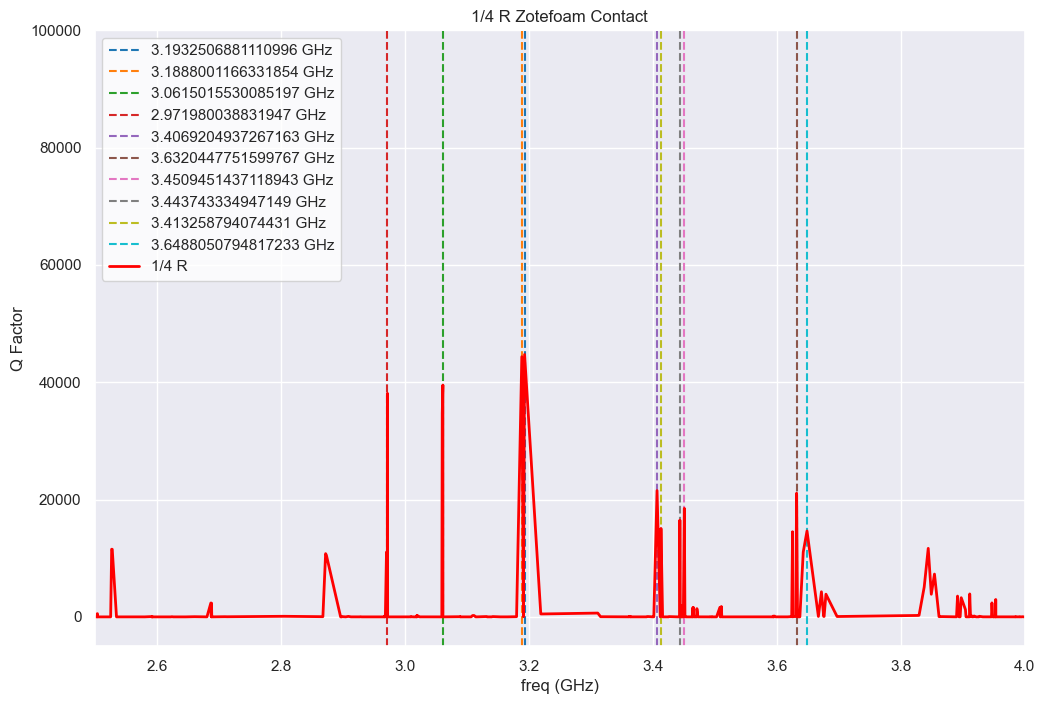

In [83]:
plt.figure(figsize = (12, 8))
cmap = plt.get_cmap('tab10')
for i in range(10):
    color = cmap(i % cmap.N)
    plt.axvline(x=quarter_R_peaks['freqs'].loc[i], 
                ymin=0, ymax = 50000, 
                label = str(quarter_R_peaks['freqs'].loc[i]) + ' GHz', 
                ls='dashed', color = color)
plt.plot(quarter_R['Frequency (GHz)'], quarter_R['Quality factor (1)'], label = '1/4 R', lw=2, color = 'red')
plt.legend(facecolor = 'white')
plt.xlim(2.5, 4)
plt.ylim(-5000, 100000)
plt.title('1/4 R Zotefoam Contact')
plt.xlabel('freq (GHz)')
plt.ylabel('Q Factor')

Text(0, 0.5, 'Q Factor')

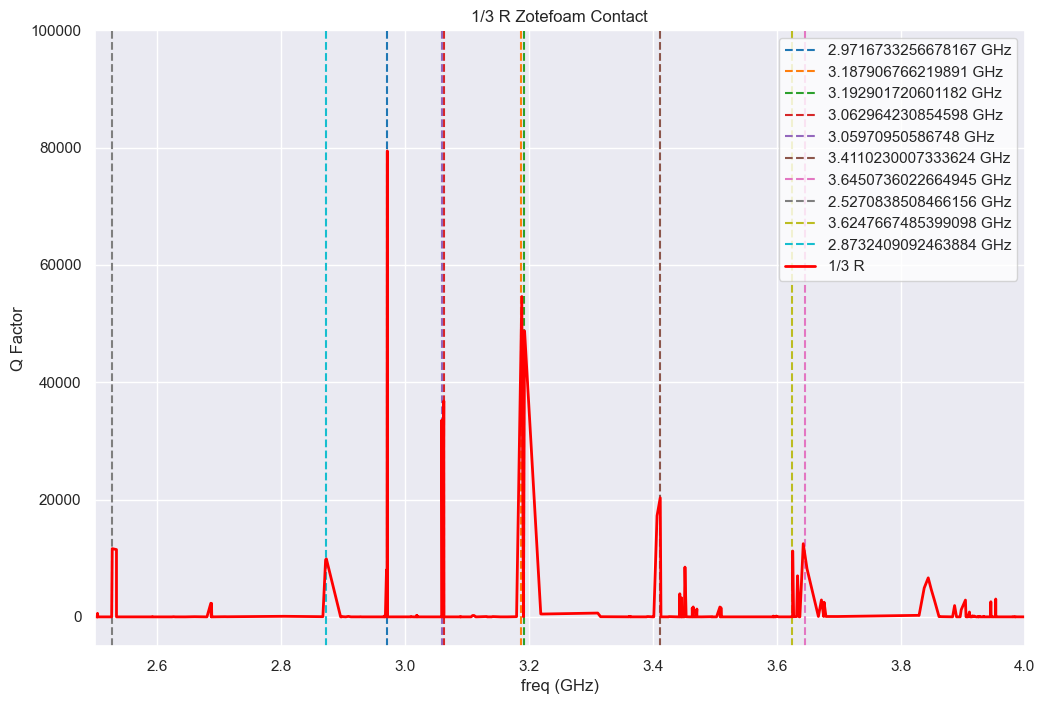

In [84]:
plt.figure(figsize = (12, 8))
cmap = plt.get_cmap('tab10')
for i in range(10):
    color = cmap(i % cmap.N)
    plt.axvline(x=third_R_peaks['freqs'].loc[i], 
                ymin=0, ymax = 100000, 
                label = str(third_R_peaks['freqs'].loc[i]) + ' GHz', 
                ls='dashed', color = color)
plt.plot(quarter_R['Frequency (GHz)'], third_R_reduced['Quality factor (1)'], label = '1/3 R', color = 'red', lw = 2)
plt.legend(facecolor='white')
plt.xlim(2.5, 4)
plt.ylim(-5000, 100000)
plt.title('1/3 R Zotefoam Contact')
plt.xlabel('freq (GHz)')
plt.ylabel('Q Factor')

Text(0, 0.5, 'Q Factor')

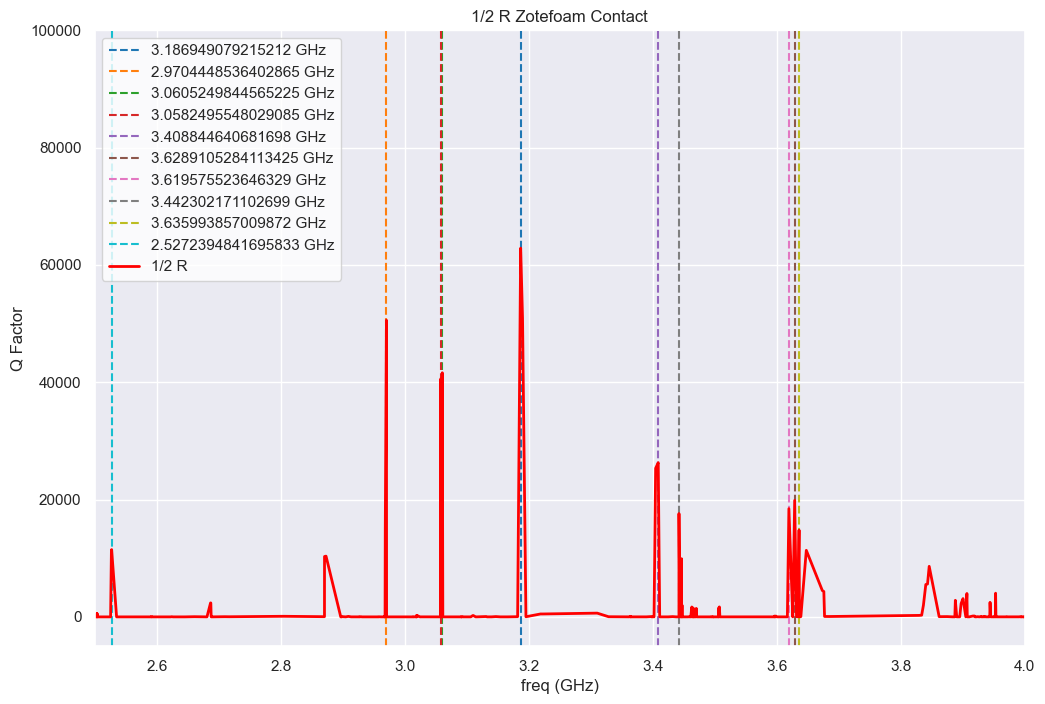

In [85]:
plt.figure(figsize = (12, 8))
cmap = plt.get_cmap('tab10')
for i in range(10):
    color = cmap(i % cmap.N)
    plt.axvline(x=half_R_peaks['freqs'].loc[i], 
                ymin=0, ymax = 100000, 
                label = str(half_R_peaks['freqs'].loc[i]) + ' GHz', 
                ls='dashed', color = color)
plt.plot(half_R_reduced['Frequency (GHz)'], half_R_reduced['Quality factor (1)'], label = '1/2 R', color = 'red', lw = 2)
plt.legend(facecolor='white')
plt.xlim(2.5, 4)
plt.ylim(-5000, 100000)
plt.title('1/2 R Zotefoam Contact')
plt.xlabel('freq (GHz)')
plt.ylabel('Q Factor')

Text(0, 0.5, 'Q Factor')

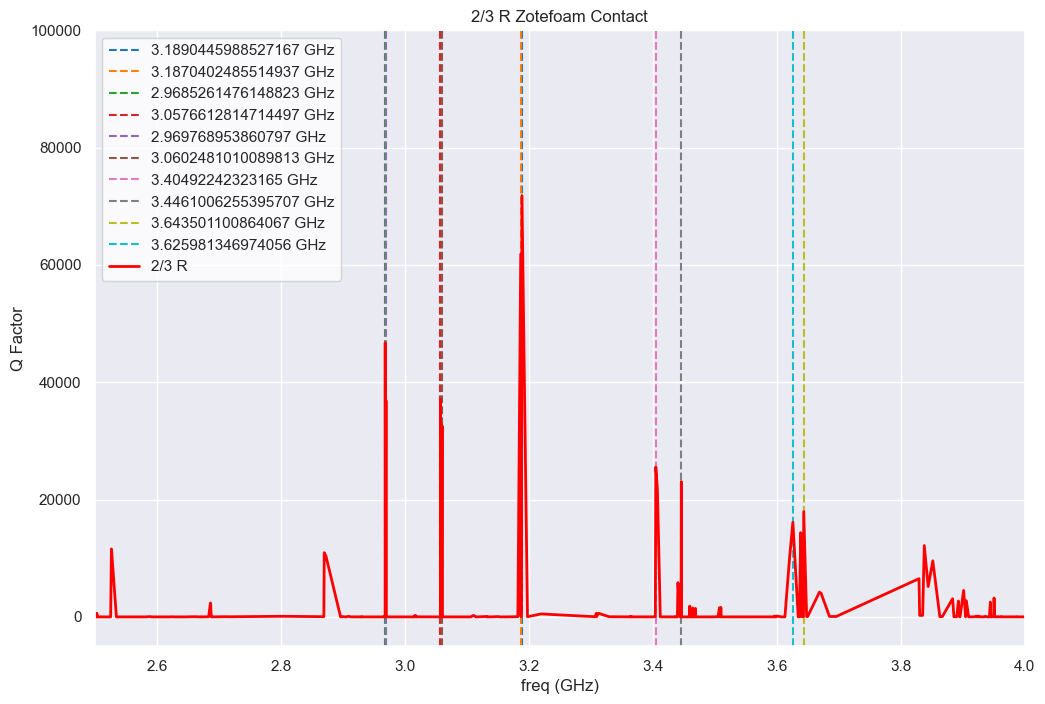

In [86]:
plt.figure(figsize = (12, 8))
cmap = plt.get_cmap('tab10')
for i in range(10):
    color = cmap(i % cmap.N)
    plt.axvline(x=twothirds_R_peaks['freqs'].loc[i], 
                ymin=0, ymax = 100000, 
                label = str(twothirds_R_peaks['freqs'].loc[i]) + ' GHz', 
                ls='dashed', color = color)
plt.plot(twothirds_R_reduced['Frequency (GHz)'], twothirds_R_reduced['Quality factor (1)'], label = '2/3 R', color = 'red', lw = 2)
plt.legend(facecolor='white')
plt.xlim(2.5, 4)
plt.ylim(-5000, 100000)
plt.title('2/3 R Zotefoam Contact')
plt.xlabel('freq (GHz)')
plt.ylabel('Q Factor')

Text(0, 0.5, 'Q Factor')

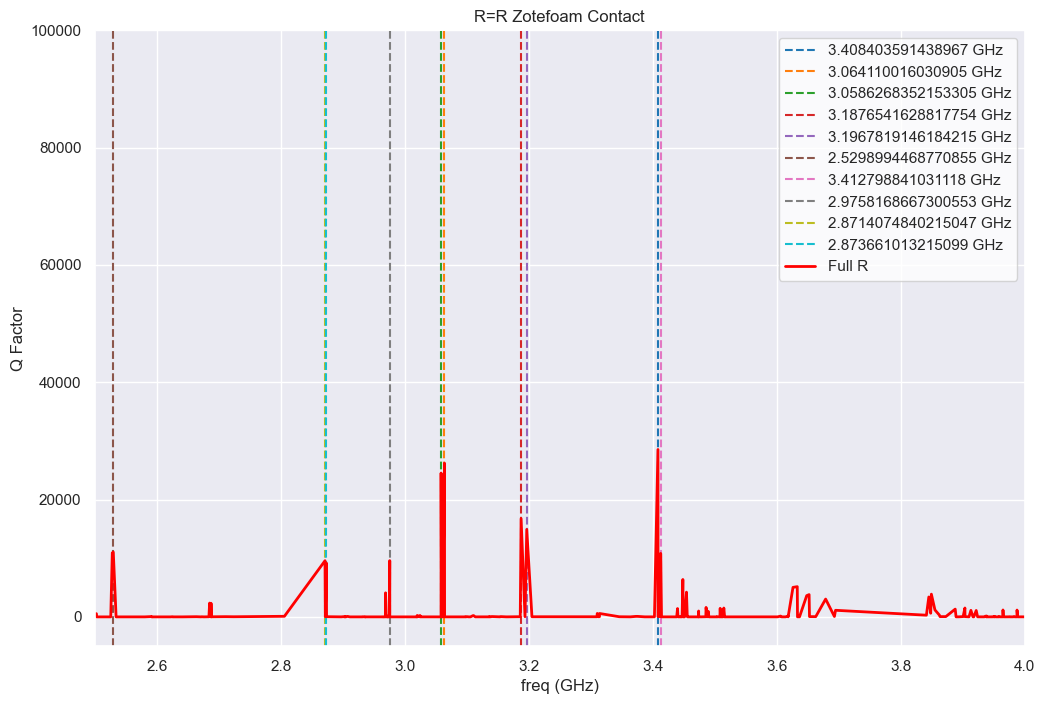

In [87]:
plt.figure(figsize = (12, 8))
cmap = plt.get_cmap('tab10')
for i in range(10):
    color = cmap(i % cmap.N)
    plt.axvline(x=full_R_peaks['freqs'].loc[i], 
                ymin=0, ymax = 100000, 
                label = str(full_R_peaks['freqs'].loc[i]) + ' GHz', 
                ls='dashed', color = color)
plt.plot(full_R_reduced['Frequency (GHz)'], full_R_reduced['Quality factor (1)'], label = 'Full R', color = 'red', lw = 2)
plt.legend(facecolor='white')
plt.xlim(2.5, 4)
plt.ylim(-5000, 100000)
plt.title('R=R Zotefoam Contact')
plt.xlabel('freq (GHz)')
plt.ylabel('Q Factor')

(3.175, 3.215)

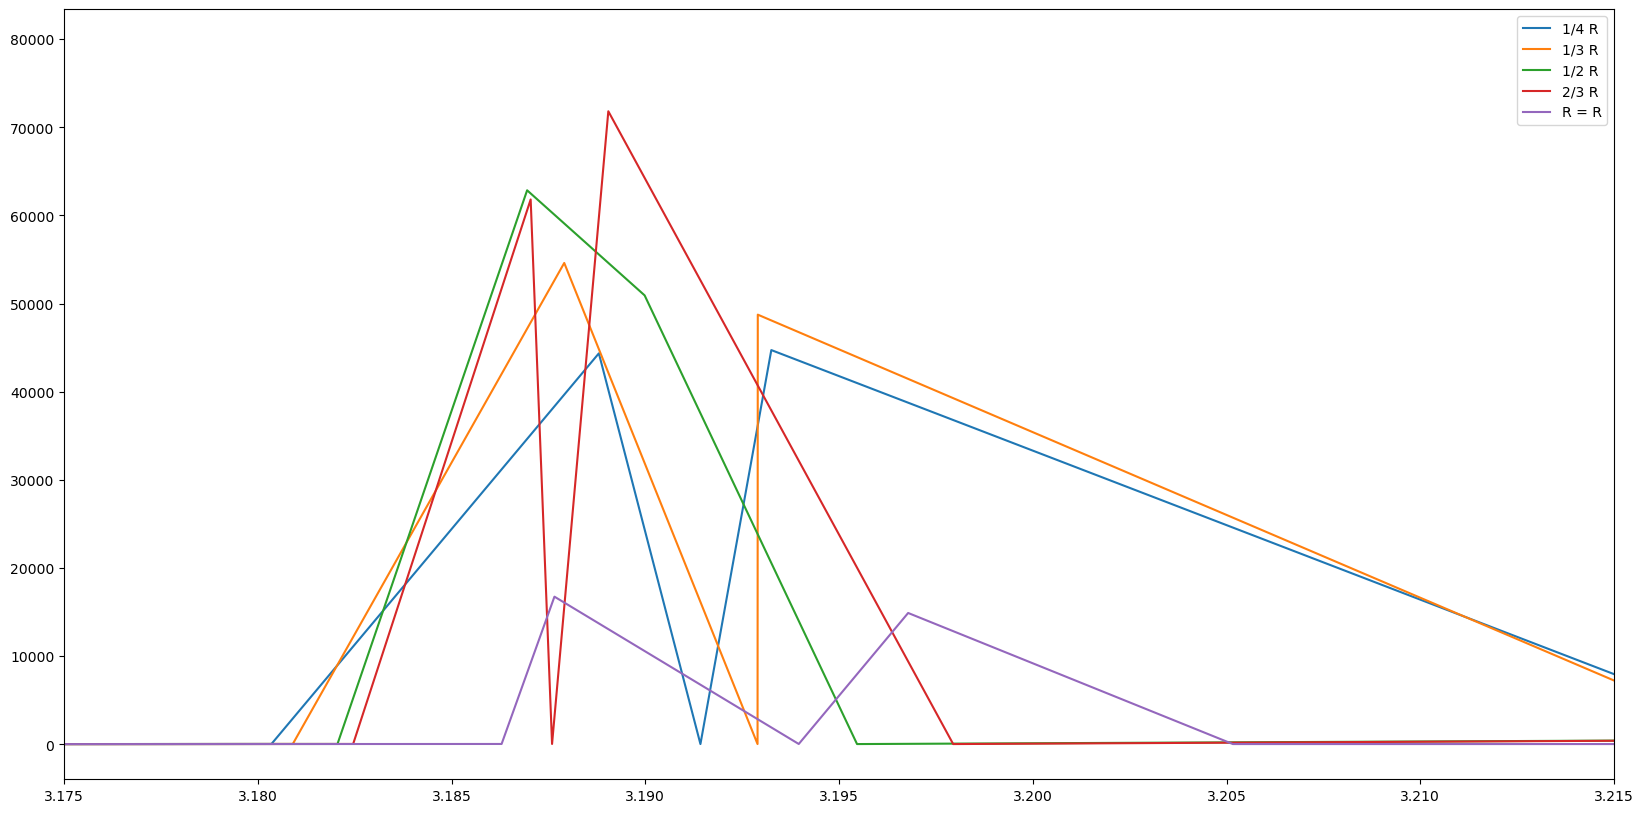

In [37]:
plt.figure(figsize = (20,10))
plt.plot(quarter_R['Frequency (GHz)'], quarter_R['Quality factor (1)'], label = '1/4 R')
plt.plot(third_R['Frequency (GHz)'], third_R['Quality factor (1)'], label = '1/3 R')
plt.plot(half_R['Frequency (GHz)'], half_R['Quality factor (1)'], label = '1/2 R')
plt.plot(twothirds_R['Frequency (GHz)'], twothirds_R['Quality factor (1)'], label = '2/3 R')
plt.plot(full_R['Frequency (GHz)'], full_R['Quality factor (1)'], label = 'R = R')
plt.legend()

plt.xlim(3.175, 3.215)

try gathering the highest-Q points for each radius, and then plotting where those high-Q points end up

(3.39, 3.425)

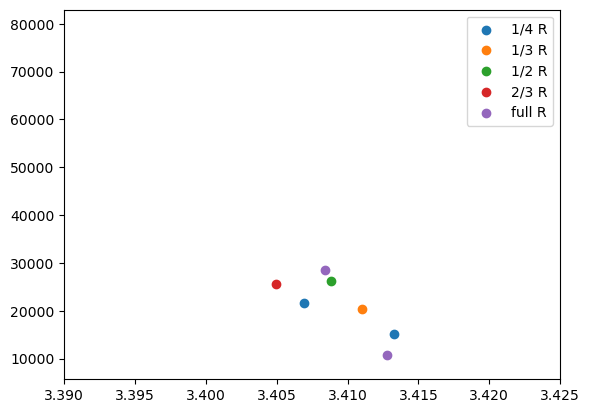

In [43]:
plt.scatter(quarter_R_peaks['freqs'], quarter_R_peaks['Q'], label = '1/4 R')
plt.scatter(third_R_peaks['freqs'], third_R_peaks['Q'], label = '1/3 R')
plt.scatter(half_R_peaks['freqs'], half_R_peaks['Q'], label = '1/2 R')
plt.scatter(twothirds_R_peaks['freqs'], twothirds_R_peaks['Q'], label = '2/3 R')
plt.scatter(full_R_peaks['freqs'], full_R_peaks['Q'], label = 'full R')
plt.legend()
plt.xlim(3.39, 3.425)

In [ ]:
quarter_R_peaks